In [ ]:
# ============================================================
# CELL 1 — Load Data & Verify Trajectory Direction
# ============================================================
# PURPOSE:
#   Load trajectory CSV + both LAS files, build the station
#   ruler, downsample point clouds, build KD-Trees, and draw
#   a sanity-check plot confirming the heading arrow points
#   along the road before any cross-section work.
#
# EXPECTED OUTPUT:
#   - Printed column names, trajectory length
#   - 2D plot with red arrow (t_hat) along road,
#     green arrow (n_hat) pointing right
#   If red arrow points ALONG the road → Cell 1 passed.
# ============================================================

import numpy as np
import pandas as pd
import laspy
from sklearn.neighbors import KDTree
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ─────────────────────────────────────────
# FILE PATHS  ← edit these
# ─────────────────────────────────────────
# ============================================================
# CELL 1 — Load Data & Verify Trajectory Direction
# ============================================================
# PURPOSE:
#   Load trajectory CSV + both LAS files, build the station
#   ruler, downsample point clouds, build KD-Trees, and draw
#   a sanity-check plot confirming the heading arrow points
#   along the road before any cross-section work.
#
# EXPECTED OUTPUT:
#   - Printed column names, trajectory length
#   - 2D plot with red arrow (t_hat) along road,
#     green arrow (n_hat) pointing right
#   If red arrow points ALONG the road → Cell 1 passed.
# ============================================================

import numpy as np
import pandas as pd
import laspy
from sklearn.neighbors import KDTree
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# FILE PATHS  ← edit these
# ─────────────────────────────────────────
SIDEWALK_LAS = r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\sidewalk.las"
LANE_LAS     = r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\Lane.las"
TRAJ_CSV     = r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\traj.csv"

# ─────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────
S_TARGET        = 596.2   # station (m) to inspect in Cell 2 / Cell 4b
HEADING_WINDOW  = 35.0   # ± metres for windowed heading average
USE_SPLINE      = True   # If True, evaluate trajectory position/heading from cubic spline x(s), y(s)
RUN_4B         = True  # If True, run Cell 4b single-station debug viewer
RUN_4C         = False  # If True, run Cell 4c batch debug export
RUN_4D         = True  # If True, run Cell 4d per-class metric statistics
VOXEL           = 0.0001   # voxel grid size (m); None to disable
HALF_THICK_U    = 0.25   # half-thickness of cross-section slab (m)
V_MIN, V_MAX    = -30, 30
QUERY_RADIUS    = 35.0   # KD-tree search radius (m)

# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────

def load_trajectory(csv_path: str):
    df = pd.read_csv(csv_path)
    print("CSV columns:", list(df.columns))

    cand_x = ["utm_e", "easting", "Easting", "east", "x", "X", "pos_x", "px", "lon", "Lon"]
    cand_y = ["utm_n", "northing", "Northing", "north", "y", "Y", "pos_y", "py", "lat", "Lat"]
    xcol = next((c for c in cand_x if c in df.columns), None)
    ycol = next((c for c in cand_y if c in df.columns), None)

    if xcol is None or ycol is None:
        raise ValueError(f"Could not auto-detect X/Y columns. Available: {list(df.columns)}")

    print(f"Using X='{xcol}', Y='{ycol}'")
    return df[[xcol, ycol]].to_numpy(float), xcol, ycol, df


def build_station_ruler(traj_xy: np.ndarray) -> np.ndarray:
    diffs = np.diff(traj_xy, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    s = np.zeros(len(traj_xy))
    s[1:] = np.cumsum(dists)
    return s


def build_trajectory_splines(s: np.ndarray, traj_xy: np.ndarray, min_ds: float = 1e-9):
    """Build cubic splines on a strictly increasing station subset."""
    if len(s) != len(traj_xy):
        raise ValueError("s and traj_xy must have the same length")

    keep = np.ones(len(s), dtype=bool)
    if len(s) >= 2:
        keep[1:] = np.diff(s) > float(min_ds)

    s_spline = s[keep]
    xy_spline = traj_xy[keep]
    dropped = int(len(s) - len(s_spline))

    if len(s_spline) < 2:
        raise ValueError("Need at least two strictly increasing trajectory stations for spline interpolation.")

    return CubicSpline(s_spline, xy_spline[:, 0]), CubicSpline(s_spline, xy_spline[:, 1]), dropped


def compute_heading(traj_xy: np.ndarray,
                    s: np.ndarray,
                    idx: int,
                    window_m: float,
                    s_target: float | None = None,
                    cs_x=None,
                    cs_y=None) -> np.ndarray | None:
    """Return a unit heading vector from either raw trajectory samples or spline geometry."""
    if s_target is None:
        s_target = float(s[idx])

    if cs_x is not None and cs_y is not None:
        deriv = np.array([float(cs_x(s_target, 1)), float(cs_y(s_target, 1))])
        length = np.linalg.norm(deriv)
        if length >= 1e-12:
            return deriv / length

        s0 = max(float(s[0]), float(s_target - window_m))
        s1 = min(float(s[-1]), float(s_target + window_m))
        if (s1 - s0) < 1e-9:
            return None
        mean_dir = np.array([float(cs_x(s1) - cs_x(s0)),
                             float(cs_y(s1) - cs_y(s0))])
        length = np.linalg.norm(mean_dir)
        return None if length < 1e-12 else mean_dir / length

    s0 = s[idx] - window_m
    s1 = s[idx] + window_m
    i0 = max(0,          int(np.searchsorted(s, s0, side="left")))
    i1 = min(len(s) - 1, int(np.searchsorted(s, s1, side="right")) - 1)

    if i1 - i0 < 2:
        return None

    steps = traj_xy[i0 + 1: i1 + 1] - traj_xy[i0: i1]
    norms = np.linalg.norm(steps, axis=1)
    steps = steps[norms > 1e-9]

    if len(steps) == 0:
        return None

    mean_dir = np.mean(steps, axis=0)
    length   = np.linalg.norm(mean_dir)
    return None if length < 1e-12 else mean_dir / length


def read_las_xyz(path: str):
    las = laspy.read(path)
    return np.asarray(las.x), np.asarray(las.y), np.asarray(las.z)


def voxel_downsample(x, y, z, voxel):
    if voxel is None:
        return x, y, z
    pts  = np.column_stack([x, y, z])
    keys = np.floor(pts / voxel).astype(np.int64)
    _, idx = np.unique(keys, axis=0, return_index=True)
    pts  = pts[idx]
    return pts[:, 0], pts[:, 1], pts[:, 2]


# ─────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────

traj_xy, xcol, ycol, dfT = load_trajectory(TRAJ_CSV)
s = build_station_ruler(traj_xy)
cs_x, cs_y, spline_drop_count = build_trajectory_splines(s, traj_xy)
print(f"\nTrajectory: {len(traj_xy)} pts, total length = {s[-1]:.1f} m")
print(f"Station range: {s[0]:.1f} → {s[-1]:.1f} m")
if spline_drop_count > 0:
    print(f"Spline prep: dropped {spline_drop_count} duplicate / non-increasing station samples")
else:
    print("Spline prep: no duplicate station samples removed")

print("\nLoading LiDAR...")
sx, sy, sz = read_las_xyz(SIDEWALK_LAS)
lx, ly, lz = read_las_xyz(LANE_LAS)
print(f"  Sidewalk raw: {len(sx):,} pts  |  Lane raw: {len(lx):,} pts")

sx, sy, sz = voxel_downsample(sx, sy, sz, VOXEL)
lx, ly, lz = voxel_downsample(lx, ly, lz, VOXEL)
print(f"  Sidewalk voxel: {len(sx):,} pts  |  Lane voxel: {len(lx):,} pts")

side_xy   = np.column_stack([sx, sy])
lane_xy   = np.column_stack([lx, ly])
side_tree = KDTree(side_xy)
lane_tree = KDTree(lane_xy)
print("\nKD-Trees built.")

# Sanity-check plot
idx_check = int(np.argmin(np.abs(s - S_TARGET)))
if USE_SPLINE:
    p_check = np.array([cs_x(S_TARGET), cs_y(S_TARGET)])
else:
    p_check = traj_xy[idx_check]
t_check   = compute_heading(
    traj_xy, s, idx_check, HEADING_WINDOW,
    s_target=float(S_TARGET),
    cs_x=cs_x if USE_SPLINE else None,
    cs_y=cs_y if USE_SPLINE else None,
)

print(f"\nAt S_TARGET={S_TARGET} m:")
print(f"  p      = {p_check}")
print(f"  t_hat  = {t_check}")

fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(traj_xy[:, 0], traj_xy[:, 1], "b-", lw=1, label="Trajectory")
ax.plot(*p_check, "ro", markersize=8, label=f"S_TARGET={S_TARGET} m")

arrow_scale = 10.0
if t_check is not None:
    n_check = np.array([t_check[1], -t_check[0]])
    ax.annotate("", xy=p_check + t_check * arrow_scale, xytext=p_check,
                arrowprops=dict(arrowstyle="->", color="red", lw=2))
    ax.annotate("", xy=p_check + n_check * arrow_scale, xytext=p_check,
                arrowprops=dict(arrowstyle="->", color="green", lw=2))
    ax.plot([], [], "r-", label="t_hat (forward along road)")
    ax.plot([], [], "g-", label="n_hat (right / lateral)")

ax.set_aspect("equal")
ax.set_title("Cell 1 — Does the red arrow point ALONG the road?")
ax.set_xlabel(xcol); ax.set_ylabel(ycol)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────
S_TARGET        = 25.5   # station (m) to inspect in Cell 2 / Cell 4b
HEADING_WINDOW  = 35.0   # ± metres for windowed heading average
VOXEL           = 0.05   # voxel grid size (m); None to disable
HALF_THICK_U    = 0.25   # half-thickness of cross-section slab (m)
V_MIN, V_MAX    = -30, 30
QUERY_RADIUS    = 35.0   # KD-tree search radius (m)

# ─────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────

def load_trajectory(csv_path: str):
    df = pd.read_csv(csv_path)
    print("CSV columns:", list(df.columns))

    cand_x = ["utm_e", "easting", "Easting", "east", "x", "X", "pos_x", "px", "lon", "Lon"]
    cand_y = ["utm_n", "northing", "Northing", "north", "y", "Y", "pos_y", "py", "lat", "Lat"]
    xcol = next((c for c in cand_x if c in df.columns), None)
    ycol = next((c for c in cand_y if c in df.columns), None)

    if xcol is None or ycol is None:
        raise ValueError(f"Could not auto-detect X/Y columns. Available: {list(df.columns)}")

    print(f"Using X='{xcol}', Y='{ycol}'")
    return df[[xcol, ycol]].to_numpy(float), xcol, ycol, df


def build_station_ruler(traj_xy: np.ndarray) -> np.ndarray:
    diffs = np.diff(traj_xy, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    s = np.zeros(len(traj_xy))
    s[1:] = np.cumsum(dists)
    return s


def build_trajectory_splines(s: np.ndarray, traj_xy: np.ndarray, min_ds: float = 1e-9):
    """Build cubic splines on a strictly increasing station subset."""
    if len(s) != len(traj_xy):
        raise ValueError("s and traj_xy must have the same length")

    keep = np.ones(len(s), dtype=bool)
    if len(s) >= 2:
        keep[1:] = np.diff(s) > float(min_ds)

    s_spline = s[keep]
    xy_spline = traj_xy[keep]
    dropped = int(len(s) - len(s_spline))

    if len(s_spline) < 2:
        raise ValueError("Need at least two strictly increasing trajectory stations for spline interpolation.")

    return CubicSpline(s_spline, xy_spline[:, 0]), CubicSpline(s_spline, xy_spline[:, 1]), dropped


def compute_heading(traj_xy: np.ndarray,
                    s: np.ndarray,
                    idx: int,
                    window_m: float,
                    s_target: float | None = None,
                    cs_x=None,
                    cs_y=None) -> np.ndarray | None:
    """Return a unit heading vector from either raw trajectory samples or spline geometry."""
    if s_target is None:
        s_target = float(s[idx])

    if cs_x is not None and cs_y is not None:
        deriv = np.array([float(cs_x(s_target, 1)), float(cs_y(s_target, 1))])
        length = np.linalg.norm(deriv)
        if length >= 1e-12:
            return deriv / length

        s0 = max(float(s[0]), float(s_target - window_m))
        s1 = min(float(s[-1]), float(s_target + window_m))
        if (s1 - s0) < 1e-9:
            return None
        mean_dir = np.array([float(cs_x(s1) - cs_x(s0)),
                             float(cs_y(s1) - cs_y(s0))])
        length = np.linalg.norm(mean_dir)
        return None if length < 1e-12 else mean_dir / length

    s0 = s[idx] - window_m
    s1 = s[idx] + window_m
    i0 = max(0,          int(np.searchsorted(s, s0, side="left")))
    i1 = min(len(s) - 1, int(np.searchsorted(s, s1, side="right")) - 1)

    if i1 - i0 < 2:
        return None

    steps = traj_xy[i0 + 1: i1 + 1] - traj_xy[i0: i1]
    norms = np.linalg.norm(steps, axis=1)
    steps = steps[norms > 1e-9]

    if len(steps) == 0:
        return None

    mean_dir = np.mean(steps, axis=0)
    length   = np.linalg.norm(mean_dir)
    return None if length < 1e-12 else mean_dir / length


def read_las_xyz(path: str):
    las = laspy.read(path)
    return np.asarray(las.x), np.asarray(las.y), np.asarray(las.z)


def voxel_downsample(x, y, z, voxel):
    if voxel is None:
        return x, y, z
    pts  = np.column_stack([x, y, z])
    keys = np.floor(pts / voxel).astype(np.int64)
    _, idx = np.unique(keys, axis=0, return_index=True)
    pts  = pts[idx]
    return pts[:, 0], pts[:, 1], pts[:, 2]


# ─────────────────────────────────────────
# EXECUTION
# ─────────────────────────────────────────

traj_xy, xcol, ycol, dfT = load_trajectory(TRAJ_CSV)
s = build_station_ruler(traj_xy)
cs_x, cs_y, spline_drop_count = build_trajectory_splines(s, traj_xy)
print(f"\nTrajectory: {len(traj_xy)} pts, total length = {s[-1]:.1f} m")
print(f"Station range: {s[0]:.1f} → {s[-1]:.1f} m")
if spline_drop_count > 0:
    print(f"Spline prep: dropped {spline_drop_count} duplicate / non-increasing station samples")
else:
    print("Spline prep: no duplicate station samples removed")

print("\nLoading LiDAR...")
sx, sy, sz = read_las_xyz(SIDEWALK_LAS)
lx, ly, lz = read_las_xyz(LANE_LAS)
print(f"  Sidewalk raw: {len(sx):,} pts  |  Lane raw: {len(lx):,} pts")

sx, sy, sz = voxel_downsample(sx, sy, sz, VOXEL)
lx, ly, lz = voxel_downsample(lx, ly, lz, VOXEL)
print(f"  Sidewalk voxel: {len(sx):,} pts  |  Lane voxel: {len(lx):,} pts")

side_xy   = np.column_stack([sx, sy])
lane_xy   = np.column_stack([lx, ly])
side_tree = KDTree(side_xy)
lane_tree = KDTree(lane_xy)
print("\nKD-Trees built.")

# Sanity-check plot
idx_check = int(np.argmin(np.abs(s - S_TARGET)))
if USE_SPLINE:
    p_check = np.array([cs_x(S_TARGET), cs_y(S_TARGET)])
else:
    p_check = traj_xy[idx_check]
t_check   = compute_heading(
    traj_xy, s, idx_check, HEADING_WINDOW,
    s_target=float(S_TARGET),
    cs_x=cs_x if USE_SPLINE else None,
    cs_y=cs_y if USE_SPLINE else None,
)

print(f"\nAt S_TARGET={S_TARGET} m:")
print(f"  p      = {p_check}")
print(f"  t_hat  = {t_check}")

fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(traj_xy[:, 0], traj_xy[:, 1], "b-", lw=1, label="Trajectory")
ax.plot(*p_check, "ro", markersize=8, label=f"S_TARGET={S_TARGET} m")

arrow_scale = 10.0
if t_check is not None:
    n_check = np.array([t_check[1], -t_check[0]])
    ax.annotate("", xy=p_check + t_check * arrow_scale, xytext=p_check,
                arrowprops=dict(arrowstyle="->", color="red", lw=2))
    ax.annotate("", xy=p_check + n_check * arrow_scale, xytext=p_check,
                arrowprops=dict(arrowstyle="->", color="green", lw=2))
    ax.plot([], [], "r-", label="t_hat (forward along road)")
    ax.plot([], [], "g-", label="n_hat (right / lateral)")

ax.set_aspect("equal")
ax.set_title("Cell 1 — Does the red arrow point ALONG the road?")
ax.set_xlabel(xcol); ax.set_ylabel(ycol)
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 2 — Single Cross-Section Extraction & Visual Check
# ============================================================
# PURPOSE:
#   Extract the 2D (v, z) profile at one station (S_TARGET)
#   and plot it. Confirm lane and sidewalk points appear on
#   the correct physical sides before running the corridor loop.
#to have been run.
#
# REQUIRES: Cell 1 
# EXPECTED OUTPUT:
#   Scatter plot:
#     - Blue   = lane points
#     - Orange = sidewalk points
#     - Black dashed line at v=0 (trajectory anchor)
#     - Red arrow  = t_hat (along road)
#     - Green arrow = n_hat (right / lateral)
#   Lane and sidewalk should form a recognisable road
#   cross-section shape.
# ============================================================


def extract_cross_section(xy_pts:  np.ndarray,
                           z_pts:   np.ndarray,
                           tree:    KDTree,
                           p:       np.ndarray,
                           t_hat:   np.ndarray,
                           half_u:  float,
                           v_min:   float,
                           v_max:   float,
                           query_r: float
                           ) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract points from a thin slab perpendicular to the road at p.

    Steps
    -----
    1. Radius query  : all points within query_r metres of p.
    2. Local frame   : project to (u=along-road, v=lateral).
    3. Slab filter   : |u| <= half_u  AND  v_min <= v <= v_max.

    Returns
    -------
    v, z : lateral coordinate and elevation of kept points.
    """
    ids = tree.query_radius(p.reshape(1, -1), r=query_r)[0]
    if len(ids) == 0:
        return np.array([]), np.array([])

    rel   = xy_pts[ids] - p
    u     = rel @ t_hat
    n_hat = np.array([t_hat[1], -t_hat[0]])   # 90° clockwise = right
    v     = rel @ n_hat

    mask  = (np.abs(u) <= half_u) & (v >= v_min) & (v <= v_max)
    return v[mask], z_pts[ids][mask]


def orient_cross_section(v_lane_raw: np.ndarray,
                          v_side_raw: np.ndarray
                          ) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Flip lateral coordinates so lane always sits on positive-v side.
    Stores near_sign for later reconstruction of world coordinates.

    Returns
    -------
    v_lane, v_side : oriented arrays
    near_sign      : +1.0 or -1.0
    """
    sign = 1.0 if (len(v_lane_raw) == 0 or np.median(v_lane_raw) >= 0) else -1.0
    return v_lane_raw * sign, v_side_raw * sign, sign


def get_physical_side_masks(v_lane: np.ndarray,
                             v_side: np.ndarray,
                             near_sign: float):
    """
    Return boolean masks selecting physical RIGHT and LEFT points
    from the oriented (near_sign-flipped) v arrays.

    When near_sign = +1: right = v >= 0, left = v <= 0  (no flip happened)
    When near_sign = -1: right = v <= 0, left = v >= 0  (flip was applied)
    """
    if near_sign >= 0:
        ml_R = v_lane >= 0;  ms_R = v_side >= 0
        ml_L = v_lane <= 0;  ms_L = v_side <= 0
    else:
        ml_R = v_lane <= 0;  ms_R = v_side <= 0
        ml_L = v_lane >= 0;  ms_L = v_side >= 0

    return ml_R, ms_R, ml_L, ms_L


# ─────────────────────────────────────────
# SINGLE-STATION EXTRACTION
# ─────────────────────────────────────────

idx   = int(np.argmin(np.abs(s - S_TARGET)))
if USE_SPLINE:
    p = np.array([cs_x(S_TARGET), cs_y(S_TARGET)])
else:
    p = traj_xy[idx]
t_hat = compute_heading(
    traj_xy, s, idx, HEADING_WINDOW,
    s_target=float(S_TARGET),
    cs_x=cs_x if USE_SPLINE else None,
    cs_y=cs_y if USE_SPLINE else None,
)
n_hat = np.array([t_hat[1], -t_hat[0]])

if t_hat is None:
    raise RuntimeError(f"Cannot compute heading at S_TARGET={S_TARGET}. Try another value.")

print(f"Station s ≈ {s[idx]:.2f} m  |  p = {p}  |  t_hat = {t_hat}")

v_lane_raw, z_lane = extract_cross_section(
    lane_xy, lz, lane_tree, p, t_hat,
    HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
)
v_side_raw, z_side = extract_cross_section(
    side_xy, sz, side_tree, p, t_hat,
    HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
)

v_lane, v_side, near_sign = orient_cross_section(v_lane_raw, v_side_raw)
ml_R, ms_R, ml_L, ms_L   = get_physical_side_masks(v_lane, v_side, near_sign)

print(f"near_sign     = {near_sign:+.0f}")
print(f"Lane points   : {len(v_lane)}  |  Sidewalk points: {len(v_side)}")
print(f"Physical RIGHT — lane: {ml_R.sum()}  sidewalk: {ms_R.sum()}")
print(f"Physical LEFT  — lane: {ml_L.sum()}  sidewalk: {ms_L.sum()}")

# ─────────────────────────────────────────
# PLOT — full cross-section
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(v_lane, z_lane, s=2, c="steelblue",  label=f"Lane  ({len(v_lane)} pts)")
ax.scatter(v_side, z_side, s=2, c="darkorange", label=f"Sidewalk ({len(v_side)} pts)")
ax.axvline(0, color="black", lw=1, ls="--", label="Trajectory anchor (v=0)")
ax.set_xlabel("v (m)  [negative=left, positive=right]")
ax.set_ylabel("z (m)")
ax.set_title(f"Cell 2 — Full Cross-Section at s ≈ {s[idx]:.1f} m  (near_sign={near_sign:+.0f})")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────
# PLOT — physical sides overlaid
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (ml, ms, side_label) in zip(axes, [
    (ml_R, ms_R, "Physical RIGHT"),
    (ml_L, ms_L, "Physical LEFT"),
]):
    ax.scatter(v_lane[ml], z_lane[ml], s=2, c="steelblue",  label=f"Lane  ({ml.sum()} pts)")
    ax.scatter(v_side[ms], z_side[ms], s=2, c="darkorange", label=f"Sidewalk ({ms.sum()} pts)")
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title(f"{side_label}  —  s ≈ {s[idx]:.1f} m")
    ax.set_xlabel("v (m)"); ax.set_ylabel("z (m)")
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle(f"Cell 2 — Physical Side Split  (near_sign={near_sign:+.0f})", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 3 — Full Corridor Loop  (builds `results`)
# ============================================================
# PURPOSE:
#   Run cross-section extraction at every STEP_SIZE metres
#   along the entire trajectory and store raw (v, z) slices.
#   This is the data-collection pass — NO classification yet.
#
# REQUIRES: Cell 1 + Cell 2 run (all helpers + KD-Trees in memory).
#
# OUTPUT:
#   results : list of dicts, one per station:
#     {
#       "s"         : float        station in metres
#       "p"         : (2,) ndarray trajectory XY
#       "t_hat"     : (2,) ndarray heading unit vector
#       "n_hat"     : (2,) ndarray lateral unit vector (right)
#       "near_sign" : float        +1 or -1
#       "v_lane"    : (K,) ndarray oriented lateral coords — lane
#       "z_lane"    : (K,) ndarray elevation — lane
#       "v_side"    : (K,) ndarray oriented lateral coords — sidewalk
#       "z_side"    : (K,) ndarray elevation — sidewalk
#       "ml_R"      : (K,) bool    physical RIGHT mask for lane
#       "ms_R"      : (K,) bool    physical RIGHT mask for sidewalk
#       "ml_L"      : (K,) bool    physical LEFT  mask for lane
#       "ms_L"      : (K,) bool    physical LEFT  mask for sidewalk
#     }
# ============================================================

STEP_SIZE = 0.2   # metres between stations
                  # Use 0.1 for full density; 0.5 is fast for testing
# ─────────────────────────────────────────
# LOOP
# ─────────────────────────────────────────
results = []
skipped = 0
stations = np.arange(0.0, s[-1], STEP_SIZE)

print(f"Corridor loop: {len(stations)} stations  (step={STEP_SIZE} m) ...")

for s_target in stations:

    # 1. Closest trajectory index
    idx = int(np.argmin(np.abs(s - s_target)))
    if USE_SPLINE:
        p = np.array([cs_x(s_target), cs_y(s_target)])
    else:
        p = traj_xy[idx]

    # 2. Windowed heading
    t_hat = compute_heading(
        traj_xy, s, idx, HEADING_WINDOW,
        s_target=float(s_target),
        cs_x=cs_x if USE_SPLINE else None,
        cs_y=cs_y if USE_SPLINE else None,
    )
    if t_hat is None:
        skipped += 1
        continue

    n_hat = np.array([t_hat[1], -t_hat[0]])

    # 3. Extract cross-sections
    v_lane_raw, z_lane = extract_cross_section(
        lane_xy, lz, lane_tree, p, t_hat,
        HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
    )
    v_side_raw, z_side = extract_cross_section(
        side_xy, sz, side_tree, p, t_hat,
        HALF_THICK_U, V_MIN, V_MAX, QUERY_RADIUS
    )

    # 4. Orient + compute physical side masks
    v_lane, v_side, near_sign = orient_cross_section(v_lane_raw, v_side_raw)
    ml_R, ms_R, ml_L, ms_L   = get_physical_side_masks(v_lane, v_side, near_sign)

    results.append({
        "s"         : float(s_target),
        "p"         : p.copy(),
        "t_hat"     : t_hat.copy(),
        "n_hat"     : n_hat.copy(),
        "near_sign" : near_sign,
        "v_lane"    : v_lane,
        "z_lane"    : z_lane,
        "v_side"    : v_side,
        "z_side"    : z_side,
        "ml_R"      : ml_R,
        "ms_R"      : ms_R,
        "ml_L"      : ml_L,
        "ms_L"      : ms_L,
    })

print(f"Done. {len(results)} stations stored, {skipped} skipped (no heading).")

# ─────────────────────────────────────────
# CORRIDOR MAP  (v vs s overview)
# ─────────────────────────────────────────
# print("Building corridor map ...")

# fig, ax = plt.subplots(figsize=(14, 8))

# for r in results:
#     st = r["s"]
#     if len(r["v_lane"]) > 0:
#         ax.scatter(
#             r["v_lane"],
#             np.full(len(r["v_lane"]), st),
#             s=0.3, c="steelblue", alpha=0.3
#         )
#     if len(r["v_side"]) > 0:
#         ax.scatter(
#             r["v_side"],
#             np.full(len(r["v_side"]), st),
#             s=0.3, c="darkorange", alpha=0.3
#         )

# ax.axvline(0, color="black", lw=0.8, ls="--")
# ax.set_xlabel("v (m)  [lateral distance from trajectory]")
# ax.set_ylabel("s (m)  [station along trajectory]")
# ax.set_title(f"Cell 3 — Corridor Map  ({len(results)} stations, step={STEP_SIZE} m)")

# from matplotlib.lines import Line2D
# ax.legend(handles=[
#     Line2D([0],[0], marker="o", color="w", markerfacecolor="steelblue",
#            markersize=6, label="Lane"),
#     Line2D([0],[0], marker="o", color="w", markerfacecolor="darkorange",
#            markersize=6, label="Sidewalk"),
# ])
# ax.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
# ============================================================
# CELL 4 — Rule-Based Ramp Classifier
# ============================================================
# PURPOSE:
#   For each station in `results`, classify the LEFT and RIGHT
#   sides independently into one of five classes:
#
#     RAMP              – gentle slope, no abrupt step, no ditch
#     CURB_NO_RAMP      – abrupt elevation step at lane/sidewalk interface
#     SEPARATED_NO_RAMP – sidewalk exists but gap from lane is too wide
#     DEPRESSED_DITCH   – profile dips below road level (concave-up valley)
#     NO_SIDEWALK       – too few sidewalk points
#     UNKNOWN           – insufficient data to classify
#
# REQUIRES: Cell 3 `results` list in memory.
#
# OUTPUT:
#   classified : list of dicts (one per station), adding:
#     {
#       "class_R", "class_L"  : string class label
#       "meta_R",  "meta_L"   : full result dict from classifier
#       "dbg_R",   "dbg_L"    : debug arrays for plotting (or None)
#     }
# ============================================================

from scipy.signal import savgol_filter
from collections import Counter

# ──────────────555555555───────────────────────────
# CLASSIFIER PARAMETERS
# ─────────────────────────────────────────
BIN_SIZE           = 0.08   # lateral bin width (m)
MIN_PTS            = 3      # min points per bin
SG_WIN             = 21     # Savitzky-Golay window (must be odd)
SG_POLY            = 4      # Savitzky-Golay polynomial degree
MIN_SW_PTS         = 50     # min sidewalk points to attempt classification
UNKNOWN_MIN_ALL_PTS = 100   # if total lane+side points are below this, classify as UNKNOWN
GAP_MAX            = 2   # max lane-sidewalk gap (m) before SEPARATED
EDGE_BAND          = 0.35   # half-width of interface zone (m)
CURB_HEIGHT_THRESH = .05   # min dz at interface to call it a curb (m)
CURB_SLOPE_THRESH  = 0.1   # min slope at interface for subtle curb
USE_DOC_KINK_METRICS = True   # True: dz/slope from smoothed profile at kink bounds (PDF style)
INTERFACE_KINK_BUFFER = 0.75  # metres; kink search window half-width around interface center
USE_DITCH_BUFFER = True   # True: evaluate ditch geometry only inside an interface-centered ditch window
DITCH_BUFFER = 1.50   # metres; ditch search window half-width around interface center
DITCH_PRIORITY_OVER_CURB = True  # True: ditch wins if both match; False: curb wins if both match


# ─────────────────────────────────────────
# PROFILE HELPERS
# ─────────────────────────────────────────

def build_binned_profile(v: np.ndarray,
                          z: np.ndarray,
                          bin_size: float = 0.05,
                          min_pts:  int   = 3
                          ) -> tuple[np.ndarray, np.ndarray]:
    """
    Aggregate raw (v, z) scatter into a 1D profile by taking
    the median elevation within each lateral bin.
    Sparse bins (< min_pts) are set to NaN for later interpolation.
    """
    v, z = np.asarray(v), np.asarray(z)
    ok   = np.isfinite(v) & np.isfinite(z)
    v, z = v[ok], z[ok]

    if len(v) == 0:
        return np.array([]), np.array([])

    edges  = np.arange(float(np.min(v)), float(np.max(v)) + bin_size, bin_size)
    if len(edges) < 2:
        edges = np.array([float(np.min(v)), float(np.max(v)) + bin_size])

    idx   = np.digitize(v, edges) - 1
    v_ctr = (edges[:-1] + edges[1:]) * 0.5
    z_med = np.full(len(v_ctr), np.nan)

    for b in range(len(v_ctr)):
        sel = (idx == b)
        if np.sum(sel) >= min_pts:
            z_med[b] = np.median(z[sel])

    return v_ctr, z_med


def smooth_savgol(z: np.ndarray,
                  win:  int = 21,
                  poly: int = 4) -> np.ndarray:
    """Savitzky-Golay smoother with auto window shrink for short arrays."""
    z   = np.asarray(z)
    win = int(win)
    if len(z) < 7:
        return z.copy()
    if win % 2 == 0:
        win += 1
    if win >= len(z):
        win = len(z) - 1 if (len(z) - 1) % 2 == 1 else len(z) - 2
    if win < 7:
        return z.copy()
    return savgol_filter(z, window_length=win, polyorder=poly, mode="interp")


def detrend_profile(v: np.ndarray,
                    z: np.ndarray
                    ) -> tuple[np.ndarray, tuple[float, float]]:
    """
    Remove a linear trend from the smoothed profile.
    Returns detrended z and (slope, intercept) of the removed trend.
    This isolates residual curvature so kinks / valleys are easier to detect
    regardless of road crown or terrain tilt.
    """
    v, z = np.asarray(v), np.asarray(z)
    ok   = np.isfinite(v) & np.isfinite(z)
    if np.sum(ok) < 2:
        return z.copy(), (0.0, 0.0)
    a, b    = np.polyfit(v[ok], z[ok], 1)
    z_dt    = z - (a * v + b)
    return z_dt, (a, b)


def build_full_profile(v_all: np.ndarray,
                       z_all: np.ndarray,
                       bin_size: float = BIN_SIZE,
                       min_pts:  int   = MIN_PTS,
                       sg_win:   int   = SG_WIN,
                       sg_poly:  int   = SG_POLY
                       ) -> dict | None:
    """
    Full pipeline: sort → bin → interpolate NaNs → smooth → detrend.
    Returns a dict of profile arrays or None if data is too sparse.
    """
    v_all, z_all = np.asarray(v_all), np.asarray(z_all)
    ok = np.isfinite(v_all) & np.isfinite(z_all)
    v_all, z_all = v_all[ok], z_all[ok]

    if len(v_all) < 20:
        return None

    order        = np.argsort(v_all)
    v_all, z_all = v_all[order], z_all[order]

    v_ctr, z_med = build_binned_profile(v_all, z_all, bin_size, min_pts)
    if len(v_ctr) == 0:
        return None

    ok2 = np.isfinite(z_med)
    if np.sum(ok2) < 12:
        return None

    # Interpolate sparse bins
    z_fill        = z_med.copy()
    z_fill[~ok2]  = np.interp(v_ctr[~ok2], v_ctr[ok2], z_fill[ok2])

    z_s           = smooth_savgol(z_fill, sg_win, sg_poly)
    z_dt, trend   = detrend_profile(v_ctr, z_s)
    d1            = np.gradient(z_dt, bin_size)
    d2            = np.gradient(d1,   bin_size)

    return {
        "v_ctr":       v_ctr,
        "z_med":       z_med,
        "z_fill":      z_fill,
        "z_s":         z_s,
        "z_dt":        z_dt,
        "d1":          d1,
        "d2":          d2,
        "trend_coef":  trend,
    }


def pick_two_kinks(v_ctr: np.ndarray,
                   z_s:   np.ndarray,
                   bin_size: float,
                   v_lo: float | None = None,
                   v_hi: float | None = None,
                   min_bins: int = 5
                   ) -> tuple[float, float, int, int, np.ndarray, str, str]:
    """
    Find two kink positions via extrema of the second derivative
    of the smoothed (not detrended) profile.

    Strategy:
      1) If an interface window [v_lo, v_hi] is valid and dense enough,
         search only inside that window.
      2) Otherwise, use profile absolute ends as fallback kinks.

    Returns
    -------
    kink1_v, kink2_v, i_k1, i_k2, d2_array, mode, note
      mode in {"interface_window", "profile_ends_fallback"}
      note explains why fallback happened (or "ok").
    """
    d1 = np.gradient(z_s, bin_size)
    d2 = np.gradient(d1, bin_size)

    use_window = False
    note = "ok"

    if v_lo is not None and v_hi is not None and np.isfinite(v_lo) and np.isfinite(v_hi):
        lo = float(min(v_lo, v_hi))
        hi = float(max(v_lo, v_hi))
        mask = (v_ctr >= lo) & (v_ctr <= hi)
        idx = np.where(mask)[0]

        if len(idx) >= int(min_bins):
            i_p = int(idx[np.argmax(d2[idx])])
            i_n = int(idx[np.argmin(d2[idx])])
            if i_p != i_n:
                use_window = True
            else:
                note = "interface_window_degenerate_extrema"
        else:
            note = "interface_window_too_sparse"
    else:
        note = "interface_window_unavailable"

    if not use_window:
        i_p = 0
        i_n = len(v_ctr) - 1
        mode = "profile_ends_fallback"
    else:
        mode = "interface_window"

    return float(v_ctr[i_p]), float(v_ctr[i_n]), i_p, i_n, d2, mode, note

def estimate_side_interface(v_lane_side: np.ndarray,
                             z_lane_side: np.ndarray,
                             v_side_side: np.ndarray,
                             z_side_side: np.ndarray,
                             edge_band: float = EDGE_BAND
                             ) -> dict | None:
    """
    Measure the elevation step at the lane/sidewalk facing edges.

    Facing-edge logic uses the same percentile edges as the
    separation/gap gate for consistency:
      Right side (median lane v >= 0): lane outer = p95(v_lane),
                                       sw inner   = p05(v_side)
      Left  side (median lane v <  0): lane outer = p05(v_lane),
                                       sw inner   = p95(v_side)

    Returns dict with gap_m, dz_edge, edge_slope or None if too sparse.
    """
    v_lane_side = np.asarray(v_lane_side); z_lane_side = np.asarray(z_lane_side)
    v_side_side = np.asarray(v_side_side); z_side_side = np.asarray(z_side_side)

    okL = np.isfinite(v_lane_side) & np.isfinite(z_lane_side)
    okS = np.isfinite(v_side_side) & np.isfinite(z_side_side)
    v_lane_side, z_lane_side = v_lane_side[okL], z_lane_side[okL]
    v_side_side, z_side_side = v_side_side[okS], z_side_side[okS]

    if len(v_lane_side) < 10 or len(v_side_side) < 10:
        return None

    on_right = np.median(v_lane_side) >= 0

    if on_right:
        lane_edge_v = float(np.percentile(v_lane_side, 95))
        side_edge_v = float(np.percentile(v_side_side,  5))
    else:
        lane_edge_v = float(np.percentile(v_lane_side,  5))
        side_edge_v = float(np.percentile(v_side_side, 95))

    lane_band = np.abs(v_lane_side - lane_edge_v) <= edge_band
    side_band = np.abs(v_side_side - side_edge_v) <= edge_band

    if np.sum(lane_band) < 3 or np.sum(side_band) < 3:
        return None

    z_lane_edge = float(np.median(z_lane_side[lane_band]))
    z_side_edge = float(np.median(z_side_side[side_band]))
    gap_m       = float(abs(side_edge_v - lane_edge_v))
    dz_edge     = float(z_side_edge - z_lane_edge)
    edge_slope  = abs(dz_edge) / max(gap_m, 1e-6)

    return {
        "lane_edge_v": lane_edge_v,
        "side_edge_v": side_edge_v,
        "z_lane_edge": z_lane_edge,
        "z_side_edge": z_side_edge,
        "gap_m":       gap_m,
        "dz_edge":     dz_edge,
        "edge_slope":  edge_slope,
    }


def classify_curb_from_interface(interface: dict | None,
                                  curb_height_thresh: float = CURB_HEIGHT_THRESH,
                                  curb_slope_thresh:  float = CURB_SLOPE_THRESH
                                  ) -> dict:
    """
    Declare a curb if the interface shows an abrupt elevation step:
      dz_edge >= curb_height_thresh
      OR  (dz_edge >= 0.025 AND edge_slope >= curb_slope_thresh)
    """
    if interface is None:
        return {"is_curb": False, "curb_reason": "no_interface"}

    dz    = abs(interface["dz_edge"])
    slope = interface["edge_slope"]
    # is_curb = (dz >= curb_height_thresh) or (dz >= 0.05 and slope >= curb_slope_thresh)
    is_curb = (dz >= CURB_HEIGHT_THRESH and slope >= CURB_SLOPE_THRESH)

    return {
        "is_curb":     bool(is_curb),
        "curb_reason": "edge_step_detected" if is_curb else "no_clear_edge_step",
        **interface,
    }


# ─────────────────────────────────────────
# DITCH DETECTOR
# ─────────────────────────────────────────

def summarize_profile_geometry(v_ctr: np.ndarray,
                                z_dt:  np.ndarray,
                                d1:    np.ndarray,
                                d2:    np.ndarray) -> dict:
    """
    Extract valley geometry from the detrended profile.
    Computes depth, width, curvature, and slope sign change
    around the minimum — all used by the ditch classifier.
    """
    i_min  = int(np.argmin(z_dt))
    i_max  = int(np.argmax(z_dt))
    zmin   = float(z_dt[i_min])
    zmax   = float(z_dt[i_max])
    vmin   = float(v_ctr[i_min])
    vmax   = float(v_ctr[i_max])

    n_end  = max(3, len(z_dt) // 5)
    zL     = float(np.median(z_dt[:n_end]))
    zR     = float(np.median(z_dt[-n_end:]))

    left_depth  = zL - zmin
    right_depth = zR - zmin
    valley_depth = min(left_depth, right_depth)

    total_width = float(v_ctr[-1] - v_ctr[0])
    dz_end      = float(zR - zL)
    avg_slope   = dz_end / max(total_width, 1e-9)

    # Slope sign change around valley bottom
    if 1 <= i_min <= len(d1) - 2:
        left_s  = float(np.median(d1[:i_min]))
        right_s = float(np.median(d1[i_min + 1:]))
        sign_change = (left_s < 0) and (right_s > 0)
    else:
        left_s = right_s = np.nan
        sign_change = False

    i0          = max(0, i_min - 1)
    i1          = min(len(d2), i_min + 2)
    valley_curv = float(np.median(d2[i0:i1]))

    # Width at half valley depth
    if valley_depth > 0:
        thresh50 = zmin + 0.5 * valley_depth
        idx50    = np.where(z_dt <= thresh50)[0]
        valley_width_50 = float(v_ctr[idx50[-1]] - v_ctr[idx50[0]]) if len(idx50) >= 2 else np.nan

        thresh30 = zmin + 0.3 * valley_depth
        idx30    = np.where(z_dt <= thresh30)[0]
        valley_width_30 = float(v_ctr[idx30[-1]] - v_ctr[idx30[0]]) if len(idx30) >= 2 else np.nan
    else:
        valley_width_50 = np.nan
        valley_width_30 = np.nan

    return {
        "i_min":                       i_min,
        "i_max":                       i_max,
        "vmin":                        vmin,
        "vmax":                        vmax,
        "zmin":                        zmin,
        "zmax":                        zmax,
        "zL":                          zL,
        "zR":                          zR,
        "left_depth":                  float(left_depth),
        "right_depth":                 float(right_depth),
        "valley_depth":                float(valley_depth),
        "total_width":                 float(total_width),
        "dz_end":                      float(dz_end),
        "avg_slope":                   float(avg_slope),
        "left_slope_median":           left_s,
        "right_slope_median":          right_s,
        "slope_sign_change_around_min":bool(sign_change),
        "valley_curv":                 float(valley_curv),
        "valley_width_50":             float(valley_width_50) if np.isfinite(valley_width_50) else np.nan,
        "valley_width_30":             float(valley_width_30) if np.isfinite(valley_width_30) else np.nan,
        "z_range":                     float(np.nanmax(z_dt) - np.nanmin(z_dt)),
    }


def classify_ditch(prof: dict | None,
                   use_buffer: bool = USE_DITCH_BUFFER,
                   v_center: float = np.nan,
                   ditch_buffer: float = DITCH_BUFFER,
                   min_bins: int = 5) -> dict:
    """
    Detect a depressed ditch / drainage channel from the detrended profile.

    When `use_buffer=True`, all ditch geometry is computed only inside
    the interface-centered window [v_center - ditch_buffer, v_center + ditch_buffer].

    Requires ALL of:
      valley_depth  >= 0.05 m
      slope sign changes around the minimum  (concave-up valley)
      curvature at valley bottom > 0.02
      valley width at half-depth >= 0.30 m
      valley width at 30% depth <= 1.10 m
    """
    out = {
        "ditch_found": False,
        "geom_class": "UNKNOWN",
        "note": "sparse_profile",
        "ditch_eval_mode": "interface_buffer" if use_buffer else "full_profile",
        "ditch_window_v0": np.nan,
        "ditch_window_v1": np.nan,
        "ditch_window_center_v": float(v_center) if np.isfinite(v_center) else np.nan,
        "ditch_window_note": "buffer_requested" if use_buffer else "buffer_disabled",
        "ditch_window_bins": np.nan,
    }
    if prof is None:
        return out

    v_use = prof["v_ctr"]
    z_use = prof["z_dt"]
    d1_use = prof["d1"]
    d2_use = prof["d2"]

    if use_buffer:
        if not np.isfinite(v_center):
            out["geom_class"] = "NOT_DITCH"
            out["note"] = "ditch_buffer_center_unavailable"
            out["ditch_window_note"] = "ditch_buffer_center_unavailable"
            return out
        v_lo = float(v_center - ditch_buffer)
        v_hi = float(v_center + ditch_buffer)
        out["ditch_window_v0"] = v_lo
        out["ditch_window_v1"] = v_hi
        mask = (prof["v_ctr"] >= v_lo) & (prof["v_ctr"] <= v_hi)
        out["ditch_window_bins"] = int(np.count_nonzero(mask))
        if np.count_nonzero(mask) < int(min_bins):
            out["geom_class"] = "NOT_DITCH"
            out["note"] = "ditch_buffer_too_sparse"
            out["ditch_window_note"] = "ditch_buffer_too_sparse"
            return out
        v_use = prof["v_ctr"][mask]
        z_use = prof["z_dt"][mask]
        d1_use = prof["d1"][mask]
        d2_use = prof["d2"][mask]
        out["ditch_window_note"] = "ok"
    else:
        out["ditch_window_v0"] = float(prof["v_ctr"][0])
        out["ditch_window_v1"] = float(prof["v_ctr"][-1])
        out["ditch_window_bins"] = int(len(prof["v_ctr"]))

    geom         = summarize_profile_geometry(v_use, z_use, d1_use, d2_use)
    valley_depth = geom["valley_depth"]
    width50      = geom["valley_width_50"]
    width30      = geom["valley_width_30"]
    curv         = geom["valley_curv"]
    sign_change  = geom["slope_sign_change_around_min"]
    left_med     = geom["left_slope_median"]
    right_med    = geom["right_slope_median"]

    # Weak sign-change fallback for shallow near-edge valleys
    weak_sign_ok = (
        np.isfinite(left_med) and np.isfinite(right_med) and
        left_med < -0.003 and right_med > -0.002
    )
    sign_ok = sign_change or weak_sign_ok

    ditch_found = bool(
        valley_depth >= 0.03 and
        sign_ok and
        curv > 0.3 and
        np.isfinite(width50) and np.isfinite(width30) and
        0.30 <= width50 and width30 <= 1.10
    )

    out.update({
        "ditch_found": ditch_found,
        "geom_class": "DEPRESSED_DITCH" if ditch_found else "NOT_DITCH",
        "note": "ok" if ditch_found else "thresholds_not_met",
    })
    out.update(geom)
    return out


# ─────────────────────────────────────────
# MAIN SIDE CLASSIFIER
# ─────────────────────────────────────────

def classify_side(v_lane: np.ndarray, z_lane: np.ndarray,
                  v_side: np.ndarray, z_side: np.ndarray,
                  bin_size:           float = BIN_SIZE,
                  min_pts:            int   = MIN_PTS,
                  sg_win:             int   = SG_WIN,
                  sg_poly:            int   = SG_POLY,
                  min_sw_pts:         int   = MIN_SW_PTS,
                  gap_max:            float = GAP_MAX,
                  edge_band:          float = EDGE_BAND,
                  curb_height_thresh: float = CURB_HEIGHT_THRESH,
                  curb_slope_thresh:  float = CURB_SLOPE_THRESH,
                  ) -> tuple[dict, dict | None]:
    """
    Classify one physical side of a cross-section.

    Decision order
    --------------
    1. NO_SIDEWALK       — too few sidewalk points
    2. SEPARATED_NO_RAMP — lane/sidewalk gap > gap_max
    3. UNKNOWN           — too few combined points or bins
    4. DEPRESSED_DITCH   — detrended profile has a concave-up valley
    5. CURB_NO_RAMP      — abrupt elevation step at the interface
    6. RAMP              — fallback: gentle transition, no step, no ditch

    Returns
    -------
    result : dict  with "class" key and supporting metrics
    dbg    : dict  of profile arrays for plotting, or None on early exit
    """

    def _empty(cls, gap=np.nan):
        return {"class": cls, "gap_m": gap,
                "dz_m": np.nan, "slope": np.nan,
                "transition_width_m": np.nan,
                "kink1_v": np.nan, "kink2_v": np.nan,
                "ambiguous": 0}, None

    # ── Infer which side we are on ───────────────────────────────────────
    on_right = (len(v_lane) == 0 or np.median(v_lane) >= 0)

    # Gate 1 — sidewalk existence
    if len(v_side) < min_sw_pts:
        return _empty("NO_SIDEWALK")

    # Gate 2 — separation check (facing-edge logic)
    gap = np.nan
    if len(v_lane) > 30 and len(v_side) > 30:
        if on_right:
            lane_edge = np.percentile(v_lane, 95)
            sw_edge   = np.percentile(v_side,  5)
        else:
            lane_edge = np.percentile(v_lane,  5)
            sw_edge   = np.percentile(v_side, 95)

        gap = float(abs(sw_edge - lane_edge))
        if gap > gap_max:
            return _empty("SEPARATED_NO_RAMP", gap)

    # Gate 3 — data sufficiency
    v_all = np.concatenate([v_lane, v_side])
    z_all = np.concatenate([z_lane, z_side])

    if len(v_all) < UNKNOWN_MIN_ALL_PTS:
        return _empty("UNKNOWN", gap)

    prof = build_full_profile(v_all, z_all, bin_size, min_pts, sg_win, sg_poly)
    if prof is None:
        return _empty("UNKNOWN", gap)

    v_ctr = prof["v_ctr"]
    z_s   = prof["z_s"]
    z_dt  = prof["z_dt"]

    # Compute interface/curb metrics early so they are available in debug
    # and to constrain kink search near the lane-sidewalk boundary.
    interface = estimate_side_interface(v_lane, z_lane, v_side, z_side, edge_band)
    curb_info = classify_curb_from_interface(interface, curb_height_thresh, curb_slope_thresh)

    interface_center_v = np.nan
    v_lo = v_hi = None
    if interface is not None and np.isfinite(interface.get("lane_edge_v", np.nan)) and np.isfinite(interface.get("side_edge_v", np.nan)):
        interface_center_v = 0.5 * float(interface["lane_edge_v"] + interface["side_edge_v"])
        v_lo = interface_center_v - INTERFACE_KINK_BUFFER
        v_hi = interface_center_v + INTERFACE_KINK_BUFFER

    # Kink info (on smoothed profile, not detrended ? more stable)
    kink1, kink2, i_k1, i_k2, d2_kink, kink_mode, kink_note = pick_two_kinks(
        v_ctr, z_s, bin_size, v_lo=v_lo, v_hi=v_hi, min_bins=5
    )
    v0, v1 = sorted([kink1, kink2])
    width = float(v1 - v0)

    # Unified kink-based transition metrics used across classes
    i0 = int(np.argmin(np.abs(v_ctr - v0)))
    i1 = int(np.argmin(np.abs(v_ctr - v1)))
    if USE_DOC_KINK_METRICS:
        dz = float(z_s[i1] - z_s[i0])
        dz_source = "smoothed_kink_bounds"
    else:
        dz = float(z_dt[i1] - z_dt[i0])
        dz_source = "detrended_kink_bounds"
    slope = abs(dz) / max(width, 1e-9)

    dbg = {
        **prof,
        "d2": d2_kink,
        "v0": v0, "v1": v1,
        "kink1": kink1, "kink2": kink2,
        "i_k1": i_k1, "i_k2": i_k2,
        "kink_mode": kink_mode,
        "kink_note": kink_note,
        "kink_window_v0": v_lo,
        "kink_window_v1": v_hi,
        "interface_center_v": interface_center_v,
        "dz_kink": dz,
        "slope_kink": slope,
        "dz_source": dz_source,
    }
    dbg.update(curb_info)
    if interface is not None:
        dbg.update(interface)

    if width <= 0.05:
        return {"class": "UNKNOWN", "note": "no_clear_kinks",
                "gap_m": gap, "dz_m": np.nan, "slope": np.nan,
                "transition_width_m": width,
                "kink1_v": kink1, "kink2_v": kink2,
                "kink_mode": kink_mode,
                "kink_note": kink_note,
                "ambiguous": 0}, dbg
    # Gate 4/5 ? ditch vs curb with configurable priority
    ditch_info = classify_ditch(
        prof,
        use_buffer=USE_DITCH_BUFFER,
        v_center=interface_center_v,
        ditch_buffer=DITCH_BUFFER,
    )
    dbg.update(ditch_info)

    curb_from_interface = bool(curb_info.get("is_curb", False))
    curb_from_kink = bool(
        abs(dz) >= curb_height_thresh and
        slope >= curb_slope_thresh
    )
    if USE_DOC_KINK_METRICS:
        is_curb = curb_from_kink
        curb_eval_mode = "kink_only"
    else:
        is_curb = curb_from_interface
        curb_eval_mode = "interface_only"
    is_ditch = bool(ditch_info.get("ditch_found", False))
    ambiguous = int(bool(is_curb and is_ditch))

    dbg["curb_from_interface"] = curb_from_interface
    dbg["curb_from_kink"] = curb_from_kink
    dbg["curb_eval_mode"] = curb_eval_mode
    dbg["is_curb"] = is_curb
    dbg["is_ditch"] = is_ditch
    dbg["priority_mode"] = "ditch_over_curb" if DITCH_PRIORITY_OVER_CURB else "curb_over_ditch"
    dbg["ambiguous"] = ambiguous

    if DITCH_PRIORITY_OVER_CURB:
        if is_ditch:
            return {
                "class":           "DEPRESSED_DITCH",
                "depth_m":         ditch_info["valley_depth"],
                "ditch_center_v":  ditch_info["vmin"],
                "ditch_width50_m": ditch_info["valley_width_50"],
                "ditch_width30_m": ditch_info["valley_width_30"],
                "ditch_curv":      ditch_info["valley_curv"],
                "gap_m":           gap,
                "dz_edge":         curb_info.get("dz_edge", np.nan),
                "edge_slope":      curb_info.get("edge_slope", np.nan),
                "curb_candidate":  bool(is_curb),
                "dz_m":            dz,
                "slope":           slope,
                "dz_source":       dz_source,
                "ambiguous":       ambiguous,
            }, dbg
        if is_curb:
            return {
                "class":      "CURB_NO_RAMP",
                "gap_m":      gap,
                "dz_edge":    curb_info.get("dz_edge", np.nan),
                "edge_slope": curb_info.get("edge_slope", np.nan),
                "dz_m":       dz,
                "slope":      slope,
                "dz_source":  dz_source,
                "curb_source": curb_eval_mode,
                "ambiguous":  ambiguous,
            }, dbg
    else:
        if is_curb:
            return {
                "class":      "CURB_NO_RAMP",
                "gap_m":      gap,
                "dz_edge":    curb_info.get("dz_edge", np.nan),
                "edge_slope": curb_info.get("edge_slope", np.nan),
                "dz_m":       dz,
                "slope":      slope,
                "dz_source":  dz_source,
                "curb_source": curb_eval_mode,
                "ambiguous":  ambiguous,
            }, dbg
        if is_ditch:
            return {
                "class":           "DEPRESSED_DITCH",
                "depth_m":         ditch_info["valley_depth"],
                "ditch_center_v":  ditch_info["vmin"],
                "ditch_width50_m": ditch_info["valley_width_50"],
                "ditch_width30_m": ditch_info["valley_width_30"],
                "ditch_curv":      ditch_info["valley_curv"],
                "gap_m":           gap,
                "dz_edge":         curb_info.get("dz_edge", np.nan),
                "edge_slope":      curb_info.get("edge_slope", np.nan),
                "curb_candidate":  bool(is_curb),
                "dz_m":            dz,
                "slope":           slope,
                "dz_source":       dz_source,
                "ambiguous":       ambiguous,
            }, dbg
    # Gate 6 ? ramp fallback
    dbg["ramp_dz_source"] = dz_source

    return {
        "class":               "RAMP",
        "dz_m":                dz,
        "slope":               slope,
        "transition_width_m":  width,
        "kink1_v":             kink1,
        "kink2_v":             kink2,
        "gap_m":               gap,
        "dz_source":           dz_source,
        "ambiguous":           ambiguous,
    }, dbg


# ─────────────────────────────────────────
# RUN CLASSIFIER ON ALL STATIONS
# ─────────────────────────────────────────
classified = []

for r in results:
    vl, zl   = r["v_lane"], r["z_lane"]
    vs, zs   = r["v_side"], r["z_side"]
    ml_R, ms_R = r["ml_R"], r["ms_R"]
    ml_L, ms_L = r["ml_L"], r["ms_L"]

    res_R, dbg_R = classify_side(vl[ml_R], zl[ml_R], vs[ms_R], zs[ms_R])
    res_L, dbg_L = classify_side(vl[ml_L], zl[ml_L], vs[ms_L], zs[ms_L])

    classified.append({
        **r,
        "class_R": res_R["class"],
        "class_L": res_L["class"],
        "meta_R":  res_R,
        "meta_L":  res_L,
        "dbg_R":   dbg_R,
        "dbg_L":   dbg_L,
    })

# ─────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────
cnt_R = Counter(r["class_R"] for r in classified)
cnt_L = Counter(r["class_L"] for r in classified)

print(f"Classified {len(classified)} stations\n")
print("RIGHT side:")
for cls, n in sorted(cnt_R.items()):
    print(f"  {cls:25s}: {n:5d}  ({100*n/len(classified):.1f}%)")
print("\nLEFT side:")
for cls, n in sorted(cnt_L.items()):
    print(f"  {cls:25s}: {n:5d}  ({100*n/len(classified):.1f}%)")

# ─────────────────────────────────────────
# QUICK VISUAL — one example per class (RIGHT side)
# ─────────────────────────────────────────
def plot_single_station(r: dict, side: str):
    """Quick scatter + smoothed profile + kinks for one station/side."""
    ml = r[f"ml_{side}"]
    ms = r[f"ms_{side}"]
    vl = r["v_lane"][ml];  zl = r["z_lane"][ml]
    vs = r["v_side"][ms];  zs = r["z_side"][ms]
    dbg = r[f"dbg_{side}"]
    cls = r[f"class_{side}"]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(vl, zl, s=2, c="steelblue",  label=f"Lane  ({len(vl)} pts)")
    ax.scatter(vs, zs, s=2, c="darkorange", label=f"Sidewalk ({len(vs)} pts)")

    if dbg is not None:
        ax.plot(dbg["v_ctr"], dbg["z_s"],  lw=2, c="black",  label="Smoothed")
        ax.plot(dbg["v_ctr"], dbg["z_dt"], lw=1.5, c="purple",
                ls="--", label="Detrended")
        ax.axvline(dbg["v0"], ls="--", c="red",   lw=1.5,
                   label=f"kink v0={dbg['v0']:.2f} m")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5,
                   label=f"kink v1={dbg['v1']:.2f} m")
        if "vmin" in dbg and np.isfinite(dbg.get("vmin", np.nan)):
            ax.axvline(dbg["vmin"], ls=":", c="purple", lw=1.5,
                       label=f"ditch center v={dbg['vmin']:.2f} m")

    ax.axvline(0, color="grey", lw=0.8, ls=":")
    ax.set_title(f"s={r['s']:.1f} m  |  {side} side  →  {cls}")
    ax.set_xlabel("v (m)"); ax.set_ylabel("z (m)")
    ax.legend(fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()


seen = set()
for r in classified:
    cls = r["class_R"]
    if cls not in seen:
        plot_single_station(r, "R")
        seen.add(cls)
    if len(seen) >= 6:
        break


Inspecting s = 722.80 m  (requested S_DEBUG = 722.8 m)
  near_sign = -1
  Physical RIGHT → DEPRESSED_DITCH   |   meta: {'class': 'DEPRESSED_DITCH', 'depth_m': 0.053786370400302985, 'ditch_center_v': -3.0852447918157964, 'ditch_width50_m': 0.4800000000000004, 'ditch_width30_m': 0.3200000000000003, 'ditch_curv': 0.8163499882263281, 'gap_m': 0.29024550019315853, 'dz_edge': 0.0, 'edge_slope': 0.0, 'curb_candidate': True, 'dz_m': -0.14362198719311436, 'slope': 0.224409354989241, 'dz_source': 'smoothed_kink_bounds', 'ambiguous': 1}
  Physical LEFT → CURB_NO_RAMP   |   meta: {'class': 'CURB_NO_RAMP', 'gap_m': 0.33975362103232065, 'dz_edge': -0.013000000000033651, 'edge_slope': 0.03826302118733553, 'dz_m': 0.060946035805613974, 'slope': 0.10883220679573914, 'dz_source': 'smoothed_kink_bounds', 'curb_source': 'kink_only', 'ambiguous': 0}


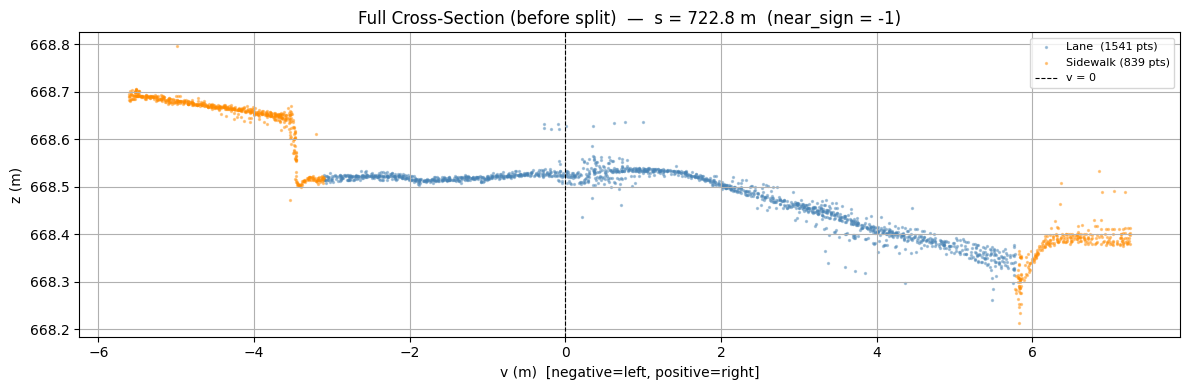

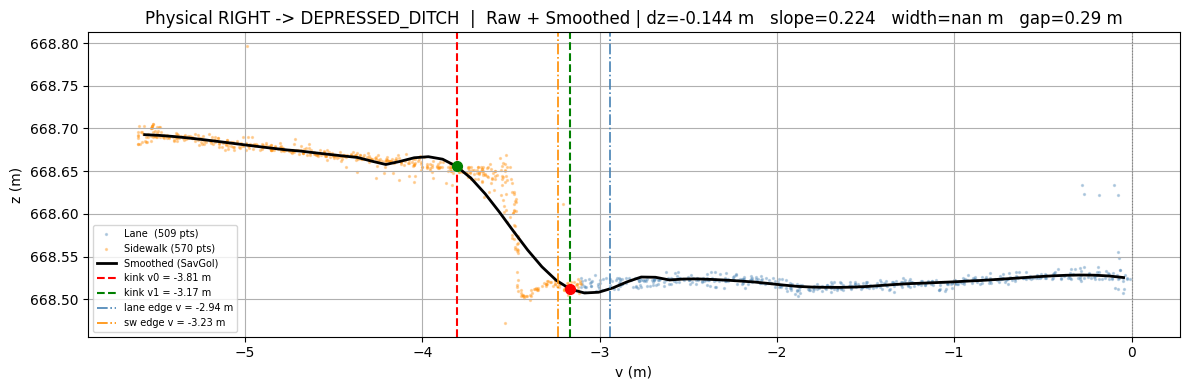

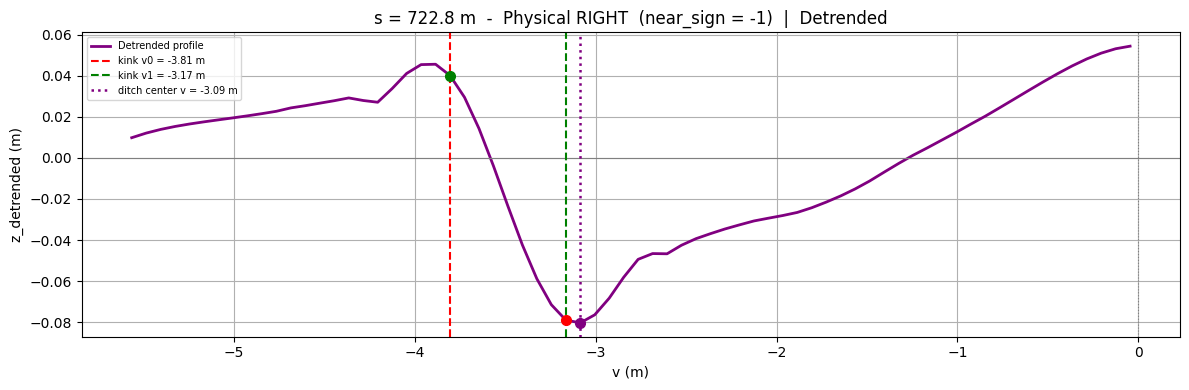

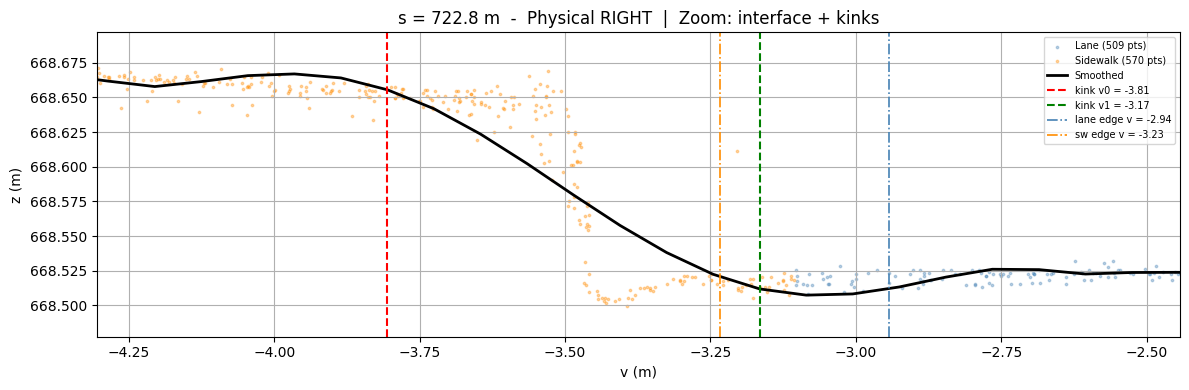

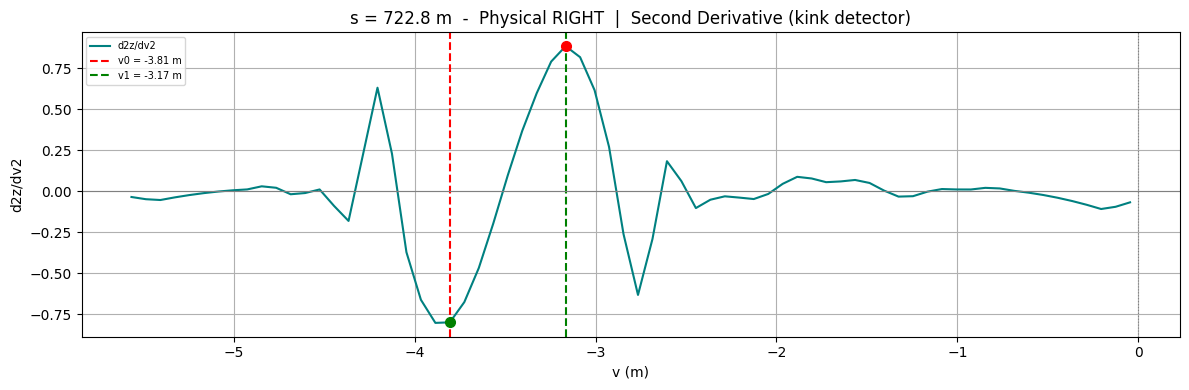


  Ditch geometry — Physical RIGHT  (class=DEPRESSED_DITCH)
    ditch_eval_mode                        : interface_buffer
    ditch_window                           : [-4.587719929158455, -1.5877199291584545]
    ditch_window_center_v                  : -3.0877199291584545
    ditch_window_note                      : ok
    valley_depth                       : 0.053786370400302985
    valley_width_50                    : 0.4800000000000004
    valley_width_30                    : 0.3200000000000003
    valley_curv                        : 0.8163499882263281
    vmin                               : -3.0852447918157964
    left_depth                         : 0.108287590717282
    right_depth                        : 0.053786370400302985
    slope_sign_change_around_min       : True

  Kink summary - Physical RIGHT  (class=DEPRESSED_DITCH)
    dz_kink(zs@v1 - zs@v0): -0.143622 m
    kink0 local: v=-3.805245, z=668.655449
    kink1 local: v=-3.165245, z=668.511827
    kink0 world: x=33225

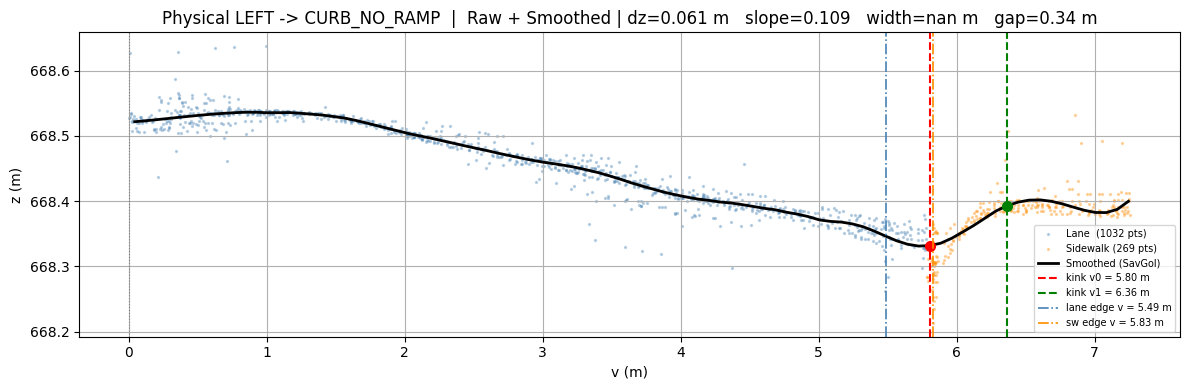

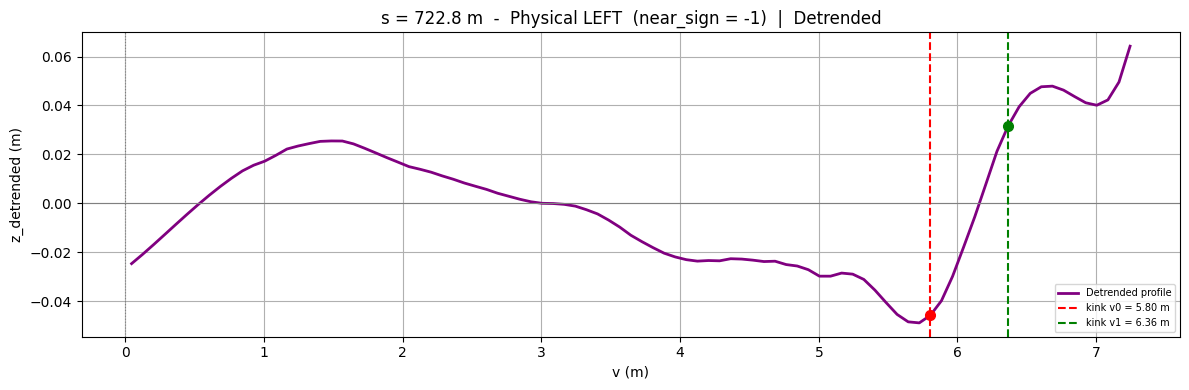

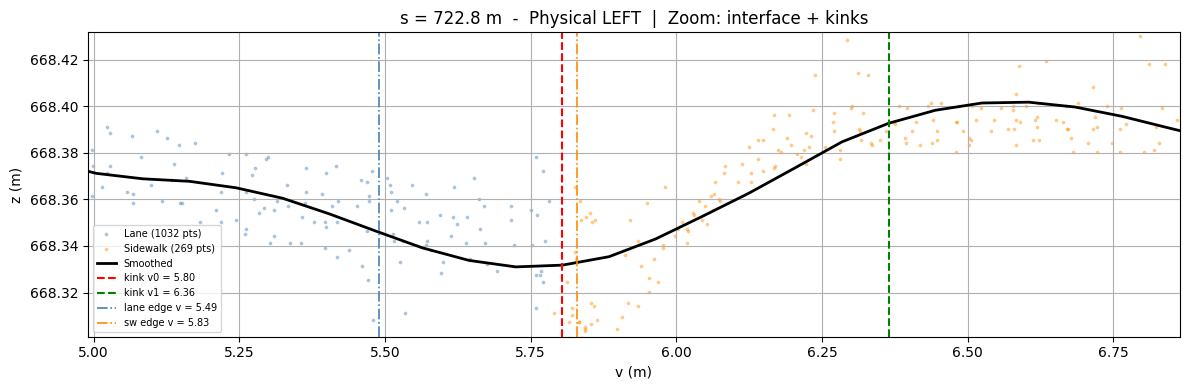

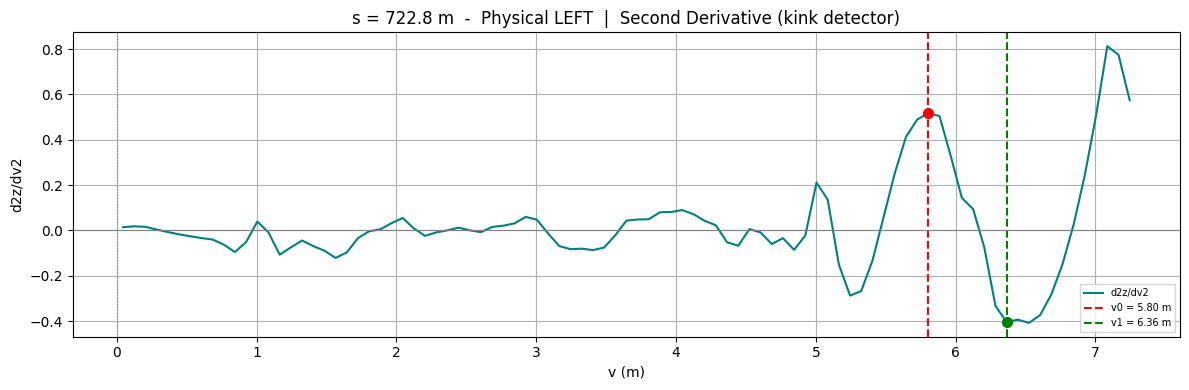


  Ditch geometry — Physical LEFT  (class=CURB_NO_RAMP)
    ditch_eval_mode                        : interface_buffer
    ditch_window                           : [4.160013200571272, 7.160013200571272]
    ditch_window_center_v                  : 5.660013200571272
    ditch_window_note                      : ok

  Kink summary - Physical LEFT  (class=CURB_NO_RAMP)
    dz_kink(zs@v1 - zs@v0): 0.060946 m
    kink0 local: v=5.804484, z=668.331774
    kink1 local: v=6.364484, z=668.392720
    kink0 world: x=332241.975270, y=5933666.319665, z=668.331774
    kink1 world: x=332241.416023, y=5933666.348691, z=668.392720

  Decision trace - Physical LEFT (class=CURB_NO_RAMP)
    [FAIL] NO_SIDEWALK        | sidewalk_pts=269 < MIN_SW_PTS=50
    [FAIL] SEPARATED_NO_RAMP  | gap_m=0.340 > GAP_MAX=2
    [FAIL] UNKNOWN            | v_all_pts=1301 < UNKNOWN_MIN_ALL_PTS=100, width=0.560
    [FAIL] DEPRESSED_DITCH    | mode=interface_buffer, window=[4.160013200571272, 7.160013200571272], note=ok, depth=0

In [10]:
if not RUN_4B: # find me
    print("Skipping Cell 4b (RUN_4B=False)")
else:
    # ============================================================
    # CELL 4b — Single-Station Debug Viewer
    # ============================================================
    # PURPOSE:
    #   Inspect the full classification at any one station in detail.
    #   Shows five plots:
    #     1) Full cross-section before left/right split
    #     2) Physical RIGHT — smoothed + detrended + kinks  (SavGol)
    #     3) Physical LEFT  — smoothed + detrended + kinks  (SavGol)
    #     4) Physical RIGHT — second derivative (kink detector)
    #     5) Physical LEFT  — second derivative (kink detector)
    #
    #   Change S_DEBUG below and re-run to inspect any station.
    #
    # REQUIRES: Cell 3 `results` + Cell 4 `classified` in memory.
    # ============================================================
    
    S_DEBUG = 722.8  # ← change this to inspect a different station
    
    # ─────────────────────────────────────────
    # FIND CLOSEST CLASSIFIED ENTRY
    # ─────────────────────────────────────────
    debug_idx = int(np.argmin(np.abs(
        np.array([r["s"] for r in classified]) - S_DEBUG
    )))
    r = classified[debug_idx]
    
    near_sign = r["near_sign"]
    label_R, label_L = "Physical RIGHT", "Physical LEFT"
    
    print(f"Inspecting s = {r['s']:.2f} m  (requested S_DEBUG = {S_DEBUG} m)")
    print(f"  near_sign = {near_sign:+.0f}")
    print(f"  {label_R} → {r['class_R']}   |   meta: {r['meta_R']}")
    print(f"  {label_L} → {r['class_L']}   |   meta: {r['meta_L']}")
    
    
    # ─────────────────────────────────────────
    # PLOT HELPERS
    # ─────────────────────────────────────────
    
    def plot_full_cross_section(r: dict):
        """Plot 1 — raw scatter of the entire cross-section before split."""
        vl, zl = r["v_lane"], r["z_lane"]
        vs, zs = r["v_side"], r["z_side"]
    
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(vl, zl, s=2, c="steelblue",  alpha=0.4, label=f"Lane  ({len(vl)} pts)")
        ax.scatter(vs, zs, s=2, c="darkorange", alpha=0.4, label=f"Sidewalk ({len(vs)} pts)")
        ax.axvline(0, color="black", lw=0.8, ls="--", label="v = 0")
        ax.set_xlabel("v (m)  [negative=left, positive=right]")
        ax.set_ylabel("z (m)")
        ax.set_title(
            f"Full Cross-Section (before split)  —  s = {r['s']:.1f} m"
            f"  (near_sign = {r['near_sign']:+.0f})"
        )
        ax.legend(fontsize=8); ax.grid(True)
        plt.tight_layout(); plt.show()
    
    
    def plot_side_debug(r: dict, side: str, phys_label: str):
        """
        Plot debug diagnostics using separate y-scales to avoid visual compression.
    
        Figure A: raw scatter + smoothed profile
        Figure B: detrended profile only
        Figure C: second derivative (kink detector)
        """
        ml  = r[f"ml_{side}"]
        ms  = r[f"ms_{side}"]
        vl  = r["v_lane"][ml];  zl = r["z_lane"][ml]
        vs  = r["v_side"][ms];  zs = r["z_side"][ms]
        dbg = r[f"dbg_{side}"]
        cls = r[f"class_{side}"]
        meta = r[f"meta_{side}"]
    
        if dbg is None:
            print(f"  {phys_label}: no debug profile available  (class={cls})")
            return
    
        v    = dbg["v_ctr"]
        z_s  = dbg["z_s"]
        z_dt = dbg["z_dt"]
        d2   = dbg["d2"]
        i_k1 = dbg["i_k1"]
        i_k2 = dbg["i_k2"]
    
        dz    = meta.get("dz_m",               np.nan)
        slope = meta.get("slope",              np.nan)
        width = meta.get("transition_width_m", np.nan)
        gap   = meta.get("gap_m",              np.nan)
    
        # Figure A: raw + smoothed (absolute elevation scale)
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(vl, zl, s=2, c="steelblue",  alpha=0.3, label=f"Lane  ({len(vl)} pts)")
        ax.scatter(vs, zs, s=2, c="darkorange", alpha=0.3, label=f"Sidewalk ({len(vs)} pts)")
        ax.plot(v, z_s, lw=2, c="black", label="Smoothed (SavGol)")
    
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"kink v0 = {dbg['v0']:.2f} m")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"kink v1 = {dbg['v1']:.2f} m")
        ax.plot(v[i_k1], z_s[i_k1], "o", ms=7, c="red")
        ax.plot(v[i_k2], z_s[i_k2], "o", ms=7, c="green")
    
        if np.isfinite(dbg.get("lane_edge_v", np.nan)):
            ax.axvline(dbg["lane_edge_v"], ls="-.", c="steelblue", lw=1.2,
                       label=f"lane edge v = {dbg['lane_edge_v']:.2f} m")
        if np.isfinite(dbg.get("side_edge_v", np.nan)):
            ax.axvline(dbg["side_edge_v"], ls="-.", c="darkorange", lw=1.2,
                       label=f"sw edge v = {dbg['side_edge_v']:.2f} m")
    
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(
            f"{phys_label} -> {cls}  |  Raw + Smoothed | "
            f"dz={dz:.3f} m   slope={slope:.3f}   width={width:.2f} m   gap={gap:.2f} m"
        )
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z (m)")
        ax.legend(fontsize=7)
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
        # Figure B: detrended only (residual scale)
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(v, z_dt, lw=2, c="purple", label="Detrended profile")
        ax.axhline(0, color="grey", lw=0.8)
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"kink v0 = {dbg['v0']:.2f} m")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"kink v1 = {dbg['v1']:.2f} m")
        ax.plot(v[i_k1], z_dt[i_k1], "o", ms=7, c="red")
        ax.plot(v[i_k2], z_dt[i_k2], "o", ms=7, c="green")
    
        if dbg.get("ditch_found", False) and np.isfinite(dbg.get("vmin", np.nan)):
            ax.axvline(dbg["vmin"], ls=":", c="purple", lw=1.8,
                       label=f"ditch center v = {dbg['vmin']:.2f} m")
            if np.isfinite(dbg.get("zmin", np.nan)):
                ax.plot(dbg["vmin"], dbg["zmin"], "o", ms=7, c="purple")
    
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"s = {r['s']:.1f} m  -  {phys_label}  (near_sign = {near_sign:+.0f})  |  Detrended")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z_detrended (m)")
        ax.legend(fontsize=7)
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
        # Figure C: zoomed raw+smoothed around interface/kinks
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(vl, zl, s=3, c="steelblue", alpha=0.35, label=f"Lane ({len(vl)} pts)")
        ax.scatter(vs, zs, s=3, c="darkorange", alpha=0.35, label=f"Sidewalk ({len(vs)} pts)")
        ax.plot(v, z_s, lw=2, c="black", label="Smoothed")
    
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"kink v0 = {dbg['v0']:.2f}")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"kink v1 = {dbg['v1']:.2f}")
    
        x_refs = [dbg["v0"], dbg["v1"]]
        if np.isfinite(dbg.get("lane_edge_v", np.nan)):
            ax.axvline(dbg["lane_edge_v"], ls="-.", c="steelblue", lw=1.2,
                       label=f"lane edge v = {dbg['lane_edge_v']:.2f}")
            x_refs.append(float(dbg["lane_edge_v"]))
        if np.isfinite(dbg.get("side_edge_v", np.nan)):
            ax.axvline(dbg["side_edge_v"], ls="-.", c="darkorange", lw=1.2,
                       label=f"sw edge v = {dbg['side_edge_v']:.2f}")
            x_refs.append(float(dbg["side_edge_v"]))
    
        zoom_x = globals().get("ZOOM_X_BUFFER", 0.50)
        zoom_y = globals().get("ZOOM_Y_BUFFER", 0.03)
    
        x_lo = min(x_refs) - zoom_x
        x_hi = max(x_refs) + zoom_x
        ax.set_xlim(x_lo, x_hi)
    
        in_zoom = (v >= x_lo) & (v <= x_hi)
        if np.any(in_zoom):
            y_zoom = z_s[in_zoom]
            y0, y1 = float(np.min(y_zoom)), float(np.max(y_zoom))
            pad = max(zoom_y, 0.10 * max(y1 - y0, 1e-6))
            ax.set_ylim(y0 - pad, y1 + pad)
    
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"s = {r['s']:.1f} m  -  {phys_label}  |  Zoom: interface + kinks")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z (m)")
        ax.legend(fontsize=7)
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
        # Figure C: second derivative
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(v, d2, c="teal", lw=1.5, label="d2z/dv2")
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"v0 = {dbg['v0']:.2f} m")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"v1 = {dbg['v1']:.2f} m")
        ax.plot(v[i_k1], d2[i_k1], "o", ms=7, c="red")
        ax.plot(v[i_k2], d2[i_k2], "o", ms=7, c="green")
        ax.axhline(0, color="grey", lw=0.8)
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"s = {r['s']:.1f} m  -  {phys_label}  |  Second Derivative (kink detector)")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("d2z/dv2")
        ax.legend(fontsize=7)
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
    def print_ditch_summary(r: dict, side: str, phys_label: str):
        dbg = r[f"dbg_{side}"]
        cls = r[f"class_{side}"]
        if dbg is None:
            return
        print(f"\n  Ditch geometry — {phys_label}  (class={cls})")
        print(f"    ditch_eval_mode{'':24s}: {dbg.get('ditch_eval_mode', 'n/a')}")
        print(f"    ditch_window{'':27s}: [{dbg.get('ditch_window_v0', np.nan)}, {dbg.get('ditch_window_v1', np.nan)}]")
        print(f"    ditch_window_center_v{'':18s}: {dbg.get('ditch_window_center_v', np.nan)}")
        print(f"    ditch_window_note{'':22s}: {dbg.get('ditch_window_note', dbg.get('note', 'n/a'))}")
        if not dbg.get("ditch_found", False):
            return
        for key in ["valley_depth", "valley_width_50", "valley_width_30", "valley_curv",
                    "vmin", "left_depth", "right_depth",
                    "slope_sign_change_around_min"]:
            val = dbg.get(key, "n/a")
            print(f"    {key:35s}: {val}")
    
    
    def print_kink_summary(r: dict, side: str, phys_label: str):
        """Print kink dz and kink points in local (v,z) and world (x,y,z)."""
        dbg = r[f"dbg_{side}"]
        cls = r[f"class_{side}"]
        if dbg is None:
            print(f"\n  Kink summary - {phys_label}  (class={cls}): no debug profile")
            return
    
        v_ctr = dbg.get("v_ctr", None)
        z_s = dbg.get("z_s", None)
        if v_ctr is None or z_s is None or len(v_ctr) == 0:
            print(f"\n  Kink summary - {phys_label}  (class={cls}): missing profile arrays")
            return
    
        v0 = float(dbg.get("v0", np.nan))
        v1 = float(dbg.get("v1", np.nan))
        if not (np.isfinite(v0) and np.isfinite(v1)):
            print(f"\n  Kink summary - {phys_label}  (class={cls}): kink bounds unavailable")
            return
    
        i0 = int(np.argmin(np.abs(v_ctr - v0)))
        i1 = int(np.argmin(np.abs(v_ctr - v1)))
    
        z0 = float(z_s[i0])
        z1 = float(z_s[i1])
        dz = float(z1 - z0)
    
        p_xy = r["p"]
        n_hat = r["n_hat"]
        near_sign = r["near_sign"]
    
        v0_raw = v0 * near_sign
        v1_raw = v1 * near_sign
    
        x0 = float(p_xy[0] + v0_raw * n_hat[0])
        y0 = float(p_xy[1] + v0_raw * n_hat[1])
        x1 = float(p_xy[0] + v1_raw * n_hat[0])
        y1 = float(p_xy[1] + v1_raw * n_hat[1])
    
        print(f"\n  Kink summary - {phys_label}  (class={cls})")
        print(f"    dz_kink(zs@v1 - zs@v0): {dz:.6f} m")
        print(f"    kink0 local: v={v0:.6f}, z={z0:.6f}")
        print(f"    kink1 local: v={v1:.6f}, z={z1:.6f}")
        print(f"    kink0 world: x={x0:.6f}, y={y0:.6f}, z={z0:.6f}")
        print(f"    kink1 world: x={x1:.6f}, y={y1:.6f}, z={z1:.6f}")
    
    def print_decision_trace(r: dict, side: str, phys_label: str):
        """Print gate-by-gate PASS/FAIL and alternative class matches."""
        ml = r[f"ml_{side}"]
        ms = r[f"ms_{side}"]
        vl = r["v_lane"][ml]
        zl = r["z_lane"][ml]
        vs = r["v_side"][ms]
        zs = r["z_side"][ms]
    
        cls = r[f"class_{side}"]
        meta = r[f"meta_{side}"]
        dbg = r[f"dbg_{side}"]
    
        gap_raw = meta.get("gap_m", np.nan)
        gap = float(gap_raw) if np.isfinite(gap_raw) else np.nan
    
        cond_no_sidewalk = (len(vs) < MIN_SW_PTS)
        enough_for_gap = (len(vl) > 30 and len(vs) > 30)
        cond_separated = bool(enough_for_gap and np.isfinite(gap) and gap > GAP_MAX)
    
        v_all = np.concatenate([vl, vs]) if (len(vl) + len(vs)) > 0 else np.array([])
        cond_unknown_low_pts = (len(v_all) < UNKNOWN_MIN_ALL_PTS)
    
        width = np.nan
        cond_unknown_no_kinks = False
        if dbg is not None and np.isfinite(dbg.get("v0", np.nan)) and np.isfinite(dbg.get("v1", np.nan)):
            width = float(abs(dbg["v1"] - dbg["v0"]))
            cond_unknown_no_kinks = (width <= 0.05)
    
        cond_unknown_profile_sparse = (
            dbg is None and
            (not cond_no_sidewalk) and
            (not cond_separated) and
            (not cond_unknown_low_pts)
        )
        cond_unknown = bool(cond_unknown_low_pts or cond_unknown_profile_sparse or cond_unknown_no_kinks)
    
        dz_edge = meta.get("dz_edge", dbg.get("dz_edge", np.nan) if dbg is not None else np.nan)
        edge_slope = meta.get("edge_slope", dbg.get("edge_slope", np.nan) if dbg is not None else np.nan)
        dz_kink = meta.get("dz_m", dbg.get("dz_kink", np.nan) if dbg is not None else np.nan)
        slope_kink = meta.get("slope", dbg.get("slope_kink", np.nan) if dbg is not None else np.nan)
        dz_source = meta.get("dz_source", dbg.get("dz_source", "n/a") if dbg is not None else "n/a")
    
        cond_curb_interface = bool(
            np.isfinite(dz_edge) and np.isfinite(edge_slope) and
            abs(float(dz_edge)) >= CURB_HEIGHT_THRESH and
            float(edge_slope) >= CURB_SLOPE_THRESH
        )
        cond_curb_kink = bool(
            np.isfinite(dz_kink) and np.isfinite(slope_kink) and
            abs(float(dz_kink)) >= CURB_HEIGHT_THRESH and
            float(slope_kink) >= CURB_SLOPE_THRESH
        )
    
        curb_eval_mode = dbg.get("curb_eval_mode", "kink_only" if USE_DOC_KINK_METRICS else "interface_only") if dbg is not None else ("kink_only" if USE_DOC_KINK_METRICS else "interface_only")
        if curb_eval_mode == "kink_only":
            cond_curb = cond_curb_kink
        else:
            cond_curb = cond_curb_interface
    
        is_curb_raw = bool(cond_curb)
        is_ditch_raw = bool(dbg is not None and dbg.get("ditch_found", False))
    
        priority_mode = (dbg.get("priority_mode", None) if dbg is not None else None)
        if priority_mode is None:
            priority_mode = "ditch_over_curb" if DITCH_PRIORITY_OVER_CURB else "curb_over_ditch"
    
        if priority_mode == "ditch_over_curb":
            cond_ditch = is_ditch_raw
            cond_curb = is_curb_raw and (not is_ditch_raw)
        else:
            cond_curb = is_curb_raw
            cond_ditch = is_ditch_raw and (not is_curb_raw)
    
        cond_ramp = bool(cls == "RAMP")
    
        checks = [
            ("NO_SIDEWALK", cond_no_sidewalk, f"sidewalk_pts={len(vs)} < MIN_SW_PTS={MIN_SW_PTS}"),
            ("SEPARATED_NO_RAMP", cond_separated,
             f"gap_m={gap:.3f} > GAP_MAX={GAP_MAX}" if np.isfinite(gap) else "gap_m unavailable"),
            ("UNKNOWN", cond_unknown,
             f"v_all_pts={len(v_all)} < UNKNOWN_MIN_ALL_PTS={UNKNOWN_MIN_ALL_PTS}, width={width:.3f}" if np.isfinite(width) else f"v_all_pts={len(v_all)} < UNKNOWN_MIN_ALL_PTS={UNKNOWN_MIN_ALL_PTS}, width=n/a"),
            ("DEPRESSED_DITCH", cond_ditch,
             f"mode={dbg.get('ditch_eval_mode', 'n/a')}, window=[{dbg.get('ditch_window_v0', np.nan)}, {dbg.get('ditch_window_v1', np.nan)}], note={dbg.get('ditch_window_note', dbg.get('note', 'n/a'))}, depth={dbg.get('valley_depth', np.nan):.3f}, width50={dbg.get('valley_width_50', np.nan):.3f}, width30={dbg.get('valley_width_30', np.nan):.3f}, curv={dbg.get('valley_curv', np.nan):.3f}" if dbg is not None else "no dbg profile"),
            ("CURB_NO_RAMP", cond_curb,
             f"edge(dz={float(dz_edge):.3f}, slope={float(edge_slope):.3f}, pass={cond_curb_interface}) | "
             f"kink(dz={float(dz_kink):.3f}, slope={float(slope_kink):.3f}, source={dz_source}, pass={cond_curb_kink})"),
            ("RAMP", cond_ramp, "fallback when all earlier gates fail"),
        ]
    
        print(f"\n  Decision trace - {phys_label} (class={cls})")
        for name, ok, detail in checks:
            print(f"    [{'PASS' if ok else 'FAIL'}] {name:18s} | {detail}")
    
        ambiguous_raw = int(bool(is_ditch_raw and is_curb_raw))
        print(f"    Priority mode: {priority_mode} | raw: ditch={is_ditch_raw}, curb={is_curb_raw}, ambiguous={ambiguous_raw} | curb_eval={curb_eval_mode} | ditch_eval={dbg.get('ditch_eval_mode', 'n/a') if dbg is not None else 'n/a'}")
        if is_curb_raw:
            used = "kink" if curb_eval_mode == "kink_only" else "edge"
            used_dz = dz_kink if curb_eval_mode == "kink_only" else dz_edge
            used_slope = slope_kink if curb_eval_mode == "kink_only" else edge_slope
            print(f"    CURB evidence used: {used} metrics | dz={float(used_dz):.3f}, slope={float(used_slope):.3f}")
    
        matched = [name for name, ok, _ in checks if ok]
        alternatives = [name for name in matched if name != cls]
    
        raw_matched = []
        if cond_no_sidewalk: raw_matched.append("NO_SIDEWALK")
        if cond_separated: raw_matched.append("SEPARATED_NO_RAMP")
        if cond_unknown: raw_matched.append("UNKNOWN")
        if is_ditch_raw: raw_matched.append("DEPRESSED_DITCH")
        if is_curb_raw: raw_matched.append("CURB_NO_RAMP")
        if cls == "RAMP": raw_matched.append("RAMP")
    
        suppressed = [x for x in raw_matched if x not in matched]
    
        if dbg is not None:
            print(
                f"    Kink search mode: {dbg.get('kink_mode', 'n/a')}"
                f" | note: {dbg.get('kink_note', 'n/a')}"
                f" | window=[{dbg.get('kink_window_v0', np.nan)}, {dbg.get('kink_window_v1', np.nan)}]"
            )
            print(
                f"    Ditch eval mode: {dbg.get('ditch_eval_mode', 'n/a')}"
                f" | note: {dbg.get('ditch_window_note', dbg.get('note', 'n/a'))}"
                f" | window=[{dbg.get('ditch_window_v0', np.nan)}, {dbg.get('ditch_window_v1', np.nan)}]"
            )
    
        print(f"    Matched rules (post-priority): {matched if matched else ['none']}")
        print(f"    Raw matched rules (pre-priority): {raw_matched if raw_matched else ['none']}")
        print(f"    Priority-suppressed matches: {suppressed if suppressed else ['none']}")
        if alternatives:
            print(f"    Also matched but lower-priority than chosen class: {alternatives}")
        else:
            print("    Also matched but lower-priority than chosen class: none")
    
    # RUN ALL PLOTS FOR THIS STATION
    # ─────────────────────────────────────────
    
    # Plot 1 — full cross-section
    plot_full_cross_section(r)
    
    # Plots 2+4 — Physical RIGHT
    plot_side_debug(r, "R", label_R)
    print_ditch_summary(r, "R", label_R)
    print_kink_summary(r, "R", label_R)
    print_decision_trace(r, "R", label_R)
    
    # Plots 3+5 — Physical LEFT
    plot_side_debug(r, "L", label_L)
    print_ditch_summary(r, "L", label_L)
    print_kink_summary(r, "L", label_L)
    print_decision_trace(r, "L", label_L)
    


In [ ]:
if not RUN_4D:
    print("Skipping Cell 4d (RUN_4D=False)")
else:
    # ============================================================
    # CELL 4d — Per-Class Metric Statistics
    # ============================================================
    # PURPOSE:
    #   Aggregate all classified stations (both sides) and show
    #   mean ± std, min, and max of the key metrics for each class.
    #
    #   Signed dz metrics (dz_edge, dz_kink) are taken as |abs|
    #   so that opposite-sign values do not cancel each other out.
    #
    #   DEPRESSED_DITCH  → valley_depth, valley_width_50, valley_width_30, valley_curv
    #   CURB_NO_RAMP     → |edge dz|, edge slope, |kink dz|, kink slope, transition_width
    #   RAMP             → |kink dz|, kink slope, transition_width_m
    #   UNKNOWN / others → |kink dz|, kink slope (where available)
    #
    # REQUIRES: Cell 4 `classified` in memory.
    # ============================================================
    
    import pandas as pd
    import warnings
    
    # ─────────────────────────────────────────
    # Columns that must be abs'd before statistics
    # (they carry a sign that can cancel across stations)
    # ─────────────────────────────────────────
    ABS_COLS = {"dz_edge", "dz_kink"}
    
    # ─────────────────────────────────────────
    # Flatten both sides into one row per (station, side)
    # ─────────────────────────────────────────
    rows = []
    for r in classified:
        for side in ("R", "L"):
            cls  = r[f"class_{side}"]
            meta = r[f"meta_{side}"]
            dbg  = r[f"dbg_{side}"]
    
            row = {"station_m": r["s"], "side": side, "class": cls}
    
            # ── DEPRESSED_DITCH metrics ──────────────────────────
            row["depth_m"]       = meta.get("depth_m",         np.nan)
            row["width50_m"]     = meta.get("ditch_width50_m", np.nan)
            row["width30_m"]     = meta.get("ditch_width30_m", np.nan)
            row["ditch_curv"]    = meta.get("ditch_curv",      np.nan)
    
            # fall back to dbg if meta doesn't carry them
            if dbg is not None and np.isnan(row["depth_m"]):
                row["depth_m"]    = dbg.get("valley_depth",     np.nan)
            if dbg is not None and np.isnan(row["width50_m"]):
                row["width50_m"]  = dbg.get("valley_width_50",  np.nan)
            if dbg is not None and np.isnan(row["width30_m"]):
                row["width30_m"]  = dbg.get("valley_width_30",  np.nan)
            if dbg is not None and np.isnan(row["ditch_curv"]):
                row["ditch_curv"] = dbg.get("valley_curv",      np.nan)
    
            # ── CURB metrics (edge + kink) — store raw; abs applied below ──
            row["dz_edge"]       = meta.get("dz_edge",    np.nan)
            row["edge_slope"]    = meta.get("edge_slope", np.nan)
            row["dz_kink"]       = meta.get("dz_m",       np.nan)   # kink-based dz
            row["kink_slope"]    = meta.get("slope",       np.nan)
            row["width_kink_m"]  = meta.get("transition_width_m", np.nan)
    
            rows.append(row)
    
    df_all = pd.DataFrame(rows)
    
    # Apply abs() to signed columns now (safe even for NaN columns)
    for col in ABS_COLS:
        if col in df_all.columns:
            df_all[col] = df_all[col].abs()
    
    # ─────────────────────────────────────────
    # Metric groups per class
    # ─────────────────────────────────────────
    CLASS_METRICS = {
        "DEPRESSED_DITCH": {
            "Valley depth (m)":          "depth_m",
            "Valley width@50% (m)":      "width50_m",
            "Valley width@30% (m)":      "width30_m",
            "Valley curvature":          "ditch_curv",
        },
        "CURB_NO_RAMP": {
            "|Edge dz| (m)":             "dz_edge",
            "Edge slope":                "edge_slope",
            "|Kink dz| (m)":             "dz_kink",
            "Kink slope":                "kink_slope",
            "Kink transition width (m)": "width_kink_m",
        },
        "RAMP": {
            "|Kink dz| (m)":             "dz_kink",
            "Kink slope":                "kink_slope",
            "Transition width (m)":      "width_kink_m",
        },
        "UNKNOWN": {
            "|Kink dz| (m)":             "dz_kink",
            "Kink slope":                "kink_slope",
        },
        "NO_SIDEWALK": {},
        "SEPARATED_NO_RAMP": {
            "|Kink dz| (m)":             "dz_kink",
            "Kink slope":                "kink_slope",
        },
    }
    
    # ─────────────────────────────────────────
    # Print per-class summary tables
    # ─────────────────────────────────────────
    all_classes = df_all["class"].unique()
    print(f"{'='*72}")
    print(f"  Per-Class Metric Statistics   ({len(df_all)} side-stations total)")
    print(f"  Note: dz metrics are |absolute| to prevent sign cancellation")
    print(f"{'='*72}")
    
    for cls in sorted(all_classes):
        subset  = df_all[df_all["class"] == cls]
        n_total = len(subset)
        metrics = CLASS_METRICS.get(cls, {})
    
        print(f"\n{'─'*72}")
        print(f"  CLASS: {cls}   (n = {n_total} side-stations)")
        print(f"{'─'*72}")
    
        if not metrics:
            print("  (no numeric metrics tracked for this class)")
            continue
    
        # Build a summary DataFrame
        stat_rows = []
        for label, col in metrics.items():
            vals = subset[col].dropna()
            n_valid = len(vals)
            if n_valid == 0:
                stat_rows.append({
                    "Metric": label, "n": 0,
                    "Mean": np.nan, "Std": np.nan,
                    "Min":  np.nan, "Max": np.nan,
                })
            else:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    stat_rows.append({
                        "Metric": label,
                        "n":      n_valid,
                        "Mean":   float(np.mean(vals)),
                        "Std":    float(np.std(vals, ddof=1)) if n_valid > 1 else np.nan,
                        "Min":    float(np.min(vals)),
                        "Max":    float(np.max(vals)),
                    })
    
        df_stats = pd.DataFrame(stat_rows).set_index("Metric")
        with pd.option_context(
            "display.float_format", "{:.4f}".format,
            "display.max_colwidth", 35,
        ):
            print(df_stats.to_string())
    
    print(f"\n{'='*72}")
    print("Done.")


In [ ]:
if not RUN_4C:
    print("Skipping Cell 4c (RUN_4C=False)")
else:
    # ============================================================
    # CELL 4c ? Batch Debug Export (All Stations)
    # ============================================================
    # PURPOSE:
    #   Save debug plots and text summaries for all stations.
    #   Output root:
    #     <input_folder>\debug\s*\
    #       - full_cross_section.png
    #       - left\*.png
    #       - right\*.png
    #       - debug.txt
    #
    # REQUIRES:
    #   Cell 4 outputs (`classified`) and Cell 1 paths (`TRAJ_CSV`) in memory.
    # ============================================================
    """
    import os
    from pathlib import Path
    import numpy as np
    import matplotlib.pyplot as plt
    # ---- Settings ----
    DEBUG_STEP = STEP_SIZE          # use same station step as corridor loop
    OVERWRITE_DEBUG = True
    ZOOM_X_BUFFER = 0.50            # metres around interface/kinks for zoom image
    ZOOM_Y_BUFFER = 0.03            # metres vertical padding for zoom image
    DEBUG_ROOT = Path(os.path.dirname(TRAJ_CSV)) / "debug"
    def _station_folder_name(s_val: float) -> str:
        txt = f"{float(s_val):.3f}".rstrip("0").rstrip(".")
        txt = txt.replace("-", "m").replace(".", "_")
        return f"s{txt}"
    def _decision_trace_data(r: dict, side: str):
        ml = r[f"ml_{side}"]
        ms = r[f"ms_{side}"]
        vl = r["v_lane"][ml]
        zl = r["z_lane"][ml]
        vs = r["v_side"][ms]
        zs = r["z_side"][ms]
        cls = r[f"class_{side}"]
        meta = r[f"meta_{side}"]
        dbg = r[f"dbg_{side}"]
    
        gap_raw = meta.get("gap_m", np.nan)
        gap = float(gap_raw) if np.isfinite(gap_raw) else np.nan
        cond_no_sidewalk = (len(vs) < MIN_SW_PTS)
        enough_for_gap = (len(vl) > 30 and len(vs) > 30)
        cond_separated = bool(enough_for_gap and np.isfinite(gap) and gap > GAP_MAX)
    
        v_all = np.concatenate([vl, vs]) if (len(vl) + len(vs)) > 0 else np.array([])
        cond_unknown_low_pts = (len(v_all) < UNKNOWN_MIN_ALL_PTS)
    
        width = np.nan
        cond_unknown_no_kinks = False
        if dbg is not None and np.isfinite(dbg.get("v0", np.nan)) and np.isfinite(dbg.get("v1", np.nan)):
            width = float(abs(dbg["v1"] - dbg["v0"]))
            cond_unknown_no_kinks = (width <= 0.05)
    
        cond_unknown_profile_sparse = (
            dbg is None and
            (not cond_no_sidewalk) and
            (not cond_separated) and
            (not cond_unknown_low_pts)
        )
        cond_unknown = bool(cond_unknown_low_pts or cond_unknown_profile_sparse or cond_unknown_no_kinks)
    
        dz_edge = meta.get("dz_edge", dbg.get("dz_edge", np.nan) if dbg is not None else np.nan)
        edge_slope = meta.get("edge_slope", dbg.get("edge_slope", np.nan) if dbg is not None else np.nan)
        dz_kink = meta.get("dz_m", dbg.get("dz_kink", np.nan) if dbg is not None else np.nan)
        slope_kink = meta.get("slope", dbg.get("slope_kink", np.nan) if dbg is not None else np.nan)
        dz_source = meta.get("dz_source", dbg.get("dz_source", "n/a") if dbg is not None else "n/a")
    
        cond_curb_interface = bool(
            np.isfinite(dz_edge) and np.isfinite(edge_slope) and
            abs(float(dz_edge)) >= CURB_HEIGHT_THRESH and
            float(edge_slope) >= CURB_SLOPE_THRESH
        )
        cond_curb_kink = bool(
            USE_DOC_KINK_METRICS and
            np.isfinite(dz_kink) and np.isfinite(slope_kink) and
            abs(float(dz_kink)) >= CURB_HEIGHT_THRESH and
            float(slope_kink) >= CURB_SLOPE_THRESH
        )
    
        curb_eval_mode = dbg.get("curb_eval_mode", "kink_only" if USE_DOC_KINK_METRICS else "interface_only") if dbg is not None else ("kink_only" if USE_DOC_KINK_METRICS else "interface_only")
        if curb_eval_mode == "kink_only":
            is_curb_raw = bool(cond_curb_kink)
        else:
            is_curb_raw = bool(cond_curb_interface)
        is_ditch_raw = bool(dbg is not None and dbg.get("ditch_found", False))
    
        priority_mode = (dbg.get("priority_mode", None) if dbg is not None else None)
        if priority_mode is None:
            priority_mode = "ditch_over_curb" if DITCH_PRIORITY_OVER_CURB else "curb_over_ditch"
    
        if priority_mode == "ditch_over_curb":
            cond_ditch = is_ditch_raw
            cond_curb = is_curb_raw and (not is_ditch_raw)
        else:
            cond_curb = is_curb_raw
            cond_ditch = is_ditch_raw and (not is_curb_raw)
    
        cond_ramp = bool(cls == "RAMP")
    
        checks = [
            ("NO_SIDEWALK", cond_no_sidewalk, f"sidewalk_pts={len(vs)} < MIN_SW_PTS={MIN_SW_PTS}"),
            ("SEPARATED_NO_RAMP", cond_separated,
             f"gap_m={gap:.3f} > GAP_MAX={GAP_MAX}" if np.isfinite(gap) else "gap_m unavailable"),
            ("UNKNOWN", cond_unknown,
             f"v_all_pts={len(v_all)} < UNKNOWN_MIN_ALL_PTS={UNKNOWN_MIN_ALL_PTS}, width={width:.3f}" if np.isfinite(width) else f"v_all_pts={len(v_all)} < UNKNOWN_MIN_ALL_PTS={UNKNOWN_MIN_ALL_PTS}, width=n/a"),
            ("DEPRESSED_DITCH", cond_ditch,
             f"mode={dbg.get('ditch_eval_mode', 'n/a')}, window=[{dbg.get('ditch_window_v0', np.nan)}, {dbg.get('ditch_window_v1', np.nan)}], note={dbg.get('ditch_window_note', dbg.get('note', 'n/a'))}, depth={dbg.get('valley_depth', np.nan):.3f}, width50={dbg.get('valley_width_50', np.nan):.3f}, width30={dbg.get('valley_width_30', np.nan):.3f}, curv={dbg.get('valley_curv', np.nan):.3f}" if dbg is not None else "no dbg profile"),
            ("CURB_NO_RAMP", cond_curb,
             f"edge(dz={float(dz_edge):.3f}, slope={float(edge_slope):.3f}, pass={cond_curb_interface}) | "
             f"kink(dz={float(dz_kink):.3f}, slope={float(slope_kink):.3f}, source={dz_source}, pass={cond_curb_kink})"),
            ("RAMP", cond_ramp, "fallback when all earlier gates fail"),
        ]
    
        matched = [name for name, ok, _ in checks if ok]
        alternatives = [name for name in matched if name != cls]
    
        raw_matched = []
        if cond_no_sidewalk: raw_matched.append("NO_SIDEWALK")
        if cond_separated: raw_matched.append("SEPARATED_NO_RAMP")
        if cond_unknown: raw_matched.append("UNKNOWN")
        if is_ditch_raw: raw_matched.append("DEPRESSED_DITCH")
        if is_curb_raw: raw_matched.append("CURB_NO_RAMP")
        if cls == "RAMP": raw_matched.append("RAMP")
    
        suppressed = [x for x in raw_matched if x not in matched]
    
        return {
            "class": cls,
            "meta": meta,
            "dbg": dbg,
            "checks": checks,
            "matched": matched,
            "alternatives": alternatives,
            "priority_mode": priority_mode,
            "is_curb_raw": is_curb_raw,
            "is_ditch_raw": is_ditch_raw,
            "ambiguous_raw": int(bool(is_curb_raw and is_ditch_raw)),
            "ditch_eval_mode": (dbg.get("ditch_eval_mode", "n/a") if dbg is not None else "n/a"),
            "raw_matched": raw_matched,
            "suppressed": suppressed,
        }
    
    def _save_full_cross_section(r: dict, out_png: Path):
        vl, zl = r["v_lane"], r["z_lane"]
        vs, zs = r["v_side"], r["z_side"]
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(vl, zl, s=2, c="steelblue", alpha=0.35, label=f"Lane ({len(vl)} pts)")
        ax.scatter(vs, zs, s=2, c="darkorange", alpha=0.35, label=f"Sidewalk ({len(vs)} pts)")
        ax.axvline(0, color="black", lw=0.8, ls="--", label="v=0")
        ax.set_title(f"Full Cross-Section  s={r['s']:.3f} m  near_sign={r['near_sign']:+.0f}")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z (m)")
        ax.legend(fontsize=8)
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(out_png, dpi=160)
        plt.close(fig)
    def _save_side_plots(r: dict, side: str, phys_label: str, out_dir: Path):
        ml = r[f"ml_{side}"]
        ms = r[f"ms_{side}"]
        vl = r["v_lane"][ml]
        zl = r["z_lane"][ml]
        vs = r["v_side"][ms]
        zs = r["z_side"][ms]
        cls = r[f"class_{side}"]
        meta = r[f"meta_{side}"]
        dbg = r[f"dbg_{side}"]
        if dbg is None:
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.scatter(vl, zl, s=2, c="steelblue", alpha=0.35, label=f"Lane ({len(vl)} pts)")
            ax.scatter(vs, zs, s=2, c="darkorange", alpha=0.35, label=f"Sidewalk ({len(vs)} pts)")
            ax.set_title(f"{phys_label} - {cls} (no debug profile)")
            ax.set_xlabel("v (m)")
            ax.set_ylabel("z (m)")
            ax.legend(fontsize=8)
            ax.grid(True)
            fig.tight_layout()
            fig.savefig(out_dir / "raw_only_no_debug.png", dpi=160)
            plt.close(fig)
            return
        v = dbg["v_ctr"]
        z_s = dbg["z_s"]
        z_dt = dbg["z_dt"]
        d2 = dbg["d2"]
        i_k1 = dbg["i_k1"]
        i_k2 = dbg["i_k2"]
        dz = meta.get("dz_m", np.nan)
        slope = meta.get("slope", np.nan)
        width = meta.get("transition_width_m", np.nan)
        gap = meta.get("gap_m", np.nan)
        # A) raw + smoothed
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(vl, zl, s=2, c="steelblue", alpha=0.30, label=f"Lane ({len(vl)} pts)")
        ax.scatter(vs, zs, s=2, c="darkorange", alpha=0.30, label=f"Sidewalk ({len(vs)} pts)")
        ax.plot(v, z_s, lw=2, c="black", label="Smoothed")
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"v0={dbg['v0']:.2f}")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"v1={dbg['v1']:.2f}")
        ax.plot(v[i_k1], z_s[i_k1], "o", ms=7, c="red")
        ax.plot(v[i_k2], z_s[i_k2], "o", ms=7, c="green")
        if np.isfinite(dbg.get("lane_edge_v", np.nan)):
            ax.axvline(dbg["lane_edge_v"], ls="-.", c="steelblue", lw=1.2,
                       label=f"lane edge v={dbg['lane_edge_v']:.2f}")
        if np.isfinite(dbg.get("side_edge_v", np.nan)):
            ax.axvline(dbg["side_edge_v"], ls="-.", c="darkorange", lw=1.2,
                       label=f"sw edge v={dbg['side_edge_v']:.2f}")
    
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"{phys_label} -> {cls} | Raw+Smoothed | dz={dz:.3f} slope={slope:.3f} width={width:.2f} gap={gap:.2f}")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z (m)")
        ax.legend(fontsize=7)
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(out_dir / "raw_smoothed.png", dpi=160)
        plt.close(fig)
        # A2) zoomed raw+smoothed around interface/kinks
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.scatter(vl, zl, s=3, c="steelblue", alpha=0.35, label=f"Lane ({len(vl)} pts)")
        ax.scatter(vs, zs, s=3, c="darkorange", alpha=0.35, label=f"Sidewalk ({len(vs)} pts)")
        ax.plot(v, z_s, lw=2, c="black", label="Smoothed")
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"v0={dbg['v0']:.2f}")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"v1={dbg['v1']:.2f}")
    
        x_refs = [dbg["v0"], dbg["v1"]]
        if np.isfinite(dbg.get("lane_edge_v", np.nan)):
            ax.axvline(dbg["lane_edge_v"], ls="-.", c="steelblue", lw=1.2,
                       label=f"lane edge v={dbg['lane_edge_v']:.2f}")
            x_refs.append(float(dbg["lane_edge_v"]))
        if np.isfinite(dbg.get("side_edge_v", np.nan)):
            ax.axvline(dbg["side_edge_v"], ls="-.", c="darkorange", lw=1.2,
                       label=f"sw edge v={dbg['side_edge_v']:.2f}")
            x_refs.append(float(dbg["side_edge_v"]))
    
        x_lo = min(x_refs) - ZOOM_X_BUFFER
        x_hi = max(x_refs) + ZOOM_X_BUFFER
        ax.set_xlim(x_lo, x_hi)
    
        in_zoom = (v >= x_lo) & (v <= x_hi)
        if np.any(in_zoom):
            y_zoom = z_s[in_zoom]
            y0, y1 = float(np.min(y_zoom)), float(np.max(y_zoom))
            pad = max(ZOOM_Y_BUFFER, 0.10 * max(y1 - y0, 1e-6))
            ax.set_ylim(y0 - pad, y1 + pad)
    
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"{phys_label} -> {cls} | Zoom: interface + kinks")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z (m)")
        ax.legend(fontsize=7)
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(out_dir / "zoom_interface_kinks.png", dpi=180)
        plt.close(fig)
    
        # B) detrended
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(v, z_dt, lw=2, c="purple", label="Detrended")
        ax.axhline(0, color="grey", lw=0.8)
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"v0={dbg['v0']:.2f}")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"v1={dbg['v1']:.2f}")
        ax.plot(v[i_k1], z_dt[i_k1], "o", ms=7, c="red")
        ax.plot(v[i_k2], z_dt[i_k2], "o", ms=7, c="green")
        if dbg.get("ditch_found", False) and np.isfinite(dbg.get("vmin", np.nan)):
            ax.axvline(dbg["vmin"], ls=":", c="purple", lw=1.8, label=f"ditch center={dbg['vmin']:.2f}")
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"{phys_label} | Detrended")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("z_detrended (m)")
        ax.legend(fontsize=7)
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(out_dir / "detrended.png", dpi=160)
        plt.close(fig)
        # C) second derivative
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(v, d2, c="teal", lw=1.5, label="d2z/dv2")
        ax.axvline(dbg["v0"], ls="--", c="red", lw=1.5, label=f"v0={dbg['v0']:.2f}")
        ax.axvline(dbg["v1"], ls="--", c="green", lw=1.5, label=f"v1={dbg['v1']:.2f}")
        ax.plot(v[i_k1], d2[i_k1], "o", ms=7, c="red")
        ax.plot(v[i_k2], d2[i_k2], "o", ms=7, c="green")
        ax.axhline(0, color="grey", lw=0.8)
        ax.axvline(0, color="grey", lw=0.8, ls=":")
        ax.set_title(f"{phys_label} | Second Derivative")
        ax.set_xlabel("v (m)")
        ax.set_ylabel("d2z/dv2")
        ax.legend(fontsize=7)
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(out_dir / "second_derivative.png", dpi=160)
        plt.close(fig)
    def _format_meta(meta: dict) -> str:
        items = []
        for k in sorted(meta.keys()):
            v = meta[k]
            if isinstance(v, float):
                if np.isfinite(v):
                    items.append(f"{k}={v:.6f}")
                else:
                    items.append(f"{k}=nan")
            else:
                items.append(f"{k}={v}")
        return ", ".join(items)
    if DEBUG_ROOT.exists() and OVERWRITE_DEBUG:
        import shutil
        shutil.rmtree(DEBUG_ROOT)
    DEBUG_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Saving batch debug to: {DEBUG_ROOT}")
    classified_s = np.array([r["s"] for r in classified], dtype=float)
    station_targets = np.arange(0.0, float(s[-1]) + 1e-9, float(DEBUG_STEP))
    for s_target in station_targets:
        idx = int(np.argmin(np.abs(classified_s - s_target)))
        r = classified[idx]
        station_dir = DEBUG_ROOT / _station_folder_name(s_target)
        left_dir = station_dir / "left"
        right_dir = station_dir / "right"
        left_dir.mkdir(parents=True, exist_ok=True)
        right_dir.mkdir(parents=True, exist_ok=True)
        _save_full_cross_section(r, station_dir / "full_cross_section.png")
        _save_side_plots(r, "R", "Physical RIGHT", right_dir)
        _save_side_plots(r, "L", "Physical LEFT", left_dir)
        tr_R = _decision_trace_data(r, "R")
        tr_L = _decision_trace_data(r, "L")
        txt = []
        txt.append(f"requested_station={s_target:.3f}")
        txt.append(f"matched_station={r['s']:.3f}")
        txt.append(f"near_sign={r['near_sign']:+.0f}")
        txt.append("")
        for side_label, tr in [("Physical RIGHT", tr_R), ("Physical LEFT", tr_L)]:
            txt.append(f"[{side_label}]")
            txt.append(f"class={tr['class']}")
            txt.append(f"meta: {_format_meta(tr['meta'])}")
            txt.append("checks:")
            for name, ok, detail in tr["checks"]:
                txt.append(f"  [{'PASS' if ok else 'FAIL'}] {name} | {detail}")
            txt.append(f"matched_rules={tr['matched']}")
            txt.append(f"alternative_matches={tr['alternatives']}")
            txt.append(f"priority_mode={tr['priority_mode']}, raw_is_ditch={tr['is_ditch_raw']}, raw_is_curb={tr['is_curb_raw']}, ambiguous_raw={tr['ambiguous_raw']}, ditch_eval_mode={tr['ditch_eval_mode']}")
            txt.append(f"raw_matched={tr['raw_matched']}")
            txt.append(f"priority_suppressed={tr['suppressed']}")
            dbg = tr["dbg"]
            if dbg is not None:
                txt.append(
                    f"kink_mode={dbg.get('kink_mode', 'n/a')}, "
                    f"kink_note={dbg.get('kink_note', 'n/a')}, "
                    f"kink_window=[{dbg.get('kink_window_v0', np.nan)}, {dbg.get('kink_window_v1', np.nan)}]"
                )
                txt.append(
                    f"ditch_eval_mode={dbg.get('ditch_eval_mode', 'n/a')}, "
                    f"ditch_note={dbg.get('ditch_window_note', dbg.get('note', 'n/a'))}, "
                    f"ditch_window=[{dbg.get('ditch_window_v0', np.nan)}, {dbg.get('ditch_window_v1', np.nan)}]"
                )
            txt.append("")
            if dbg is not None:
                txt.append("ditch_eval:")
                for key in ["ditch_eval_mode", "ditch_window_v0", "ditch_window_v1", "ditch_window_center_v",
                            "ditch_window_note", "ditch_window_bins", "note"]:
                    txt.append(f"  {key}={dbg.get(key, 'n/a')}")
                txt.append("")
            if dbg is not None and dbg.get("ditch_found", False):
                txt.append("ditch_geometry:")
                for key in ["valley_depth", "valley_width_50", "valley_width_30", "valley_curv", "vmin",
                            "left_depth", "right_depth", "slope_sign_change_around_min"]:
                    txt.append(f"  {key}={dbg.get(key, 'n/a')}")
                txt.append("")
        (station_dir / "debug.txt").write_text("\n".join(txt), encoding="utf-8")
    print(f"Done. Saved {len(station_targets)} station folders under: {DEBUG_ROOT}")
    """

In [ ]:
# ============================================================
# CELL 5 — Export to CloudCompare + Human-Readable CSV
# ============================================================
# PURPOSE:
#   Two export pairs per run:
#
#   A) Trajectory point cloud  (*_traj_CC.asc  +  *_traj.csv)
#      One point per station at the trajectory XY, colored by
#      the dominant class (higher-priority side wins).
#      Use this to see the corridor classification at a glance
#      in CloudCompare.
#
#   B) Sidewalk point cloud  (*_sidewalk_CC.asc  +  *_sidewalk.csv)
#      Every sidewalk point from every station, back-projected
#      to real-world XY using  p + v_raw * n_hat.
#      Each point carries its class color.
#      Use this to see exactly which physical sidewalk areas
#      were classified as ramps, curbs, ditches, etc.
#
# REQUIRES: Cell 4 `classified` list in memory.
# ============================================================

import pandas as pd

# ─────────────────────────────────────────
# CLASS ENCODING
# ─────────────────────────────────────────

CLASS_CODE = {
    "RAMP":              0,
    "CURB_NO_RAMP":      1,
    "SEPARATED_NO_RAMP": 2,
    "NO_SIDEWALK":       3,
    "DEPRESSED_DITCH":   4,
    "UNKNOWN":           5,
}

CLASS_COLOR = {
    "RAMP":              (0,   210,   0),   # bright green
    "CURB_NO_RAMP":      (255, 140,   0),   # orange
    "SEPARATED_NO_RAMP": (0,   100, 255),   # blue
    "NO_SIDEWALK":       (220,  50,  50),   # red
    "DEPRESSED_DITCH":   (160,  32, 240),   # purple
    "UNKNOWN":           (180, 180, 180),   # grey
}

# Lower index = higher priority when picking dominant class
PRIORITY = {name: i for i, name in enumerate(CLASS_CODE)}
INV_MAP  = {v: k for k, v in CLASS_CODE.items()}


def rgb_to_hex(r, g, b):
    return f"#{r:02X}{g:02X}{b:02X}"


def dominant_class(class_R: str, class_L: str) -> str:
    """
    Return whichever side has the higher-priority class.
    Priority: RAMP > CURB_NO_RAMP > SEPARATED_NO_RAMP >
              NO_SIDEWALK > DEPRESSED_DITCH > UNKNOWN

    Example
    -------
    >>> dominant_class("CURB_NO_RAMP", "RAMP")
    'RAMP'
    """
    if PRIORITY.get(class_R, 99) <= PRIORITY.get(class_L, 99):
        return class_R
    return class_L


print("Class encoding:")
for name, code in CLASS_CODE.items():
    r, g, b = CLASS_COLOR[name]
    print(f"  {code}  {name:25s}  RGB({r:3d},{g:3d},{b:3d})  {rgb_to_hex(r,g,b)}")

# ─────────────────────────────────────────
# TRAJECTORY Z  (from CSV if available)
# ─────────────────────────────────────────
cand_z = ["z", "Z", "alt", "altitude", "elevation",
          "Elevation", "height", "Height", "utm_z"]
zcol   = next((c for c in cand_z if c in dfT.columns), None)
traj_z = dfT[zcol].to_numpy(float) if zcol else None

if zcol:
    print(f"\nTrajectory Z column: '{zcol}'")
else:
    print("\nNo Z column found — using z = 0.0 for trajectory points")

# ─────────────────────────────────────────
# A) TRAJECTORY POINT EXPORT
# ─────────────────────────────────────────
traj_rows = []

for r in classified:
    traj_idx   = int(np.argmin(np.abs(s - r["s"])))
    if USE_SPLINE and ("p" in r):
        tx, ty = map(float, r["p"])
    else:
        tx, ty = map(float, traj_xy[traj_idx])
    tz         = float(traj_z[traj_idx]) if traj_z is not None else 0.0

    class_R    = r["class_R"]
    class_L    = r["class_L"]
    dom        = dominant_class(class_R, class_L)
    cr, cg, cb = CLASS_COLOR.get(dom, CLASS_COLOR["UNKNOWN"])

    # Dominant meta — pull supporting metrics if available
    dom_meta   = r["meta_R"] if PRIORITY.get(class_R, 99) <= PRIORITY.get(class_L, 99) \
                 else r["meta_L"]

    traj_rows.append({
        "//X":          tx,
        "Y":            ty,
        "Z":            tz,
        "R":            cr,
        "G":            cg,
        "B":            cb,
        "s_m":          round(r["s"], 3),
        "class_RIGHT":  CLASS_CODE.get(class_R, 5),
        "class_LEFT":   CLASS_CODE.get(class_L, 5),
        "label_R":      class_R,
        "label_L":      class_L,
        "ambiguous_RIGHT": int(r["meta_R"].get("ambiguous", 0)),
        "ambiguous_LEFT":  int(r["meta_L"].get("ambiguous", 0)),
        "dominant":     dom,
        "hex_R":        rgb_to_hex(*CLASS_COLOR.get(class_R, CLASS_COLOR["UNKNOWN"])),
        "hex_L":        rgb_to_hex(*CLASS_COLOR.get(class_L, CLASS_COLOR["UNKNOWN"])),
        "gap_m":        round(float(dom_meta.get("gap_m",  np.nan)), 4),
        "dz_m":         round(float(dom_meta.get("dz_m",   np.nan)), 4),
        "slope":        round(float(dom_meta.get("slope",  np.nan)), 4),
        "depth_m":      round(float(dom_meta.get("depth_m", np.nan)), 4),
    })

df_traj = pd.DataFrame(traj_rows)

# ─────────────────────────────────────────
# B) FULL SIDEWALK POINT EXPORT
# ─────────────────────────────────────────
sw_rows = []

for r in classified:
    p         = r["p"]
    n_hat     = r["n_hat"]
    near_sign = r["near_sign"]
    vs        = r["v_side"]
    zs        = r["z_side"]

    # class_R/class_L are already PHYSICAL right/left from Cell 3 masks.
    # Reuse stored sidewalk masks to avoid side flips during export.
    side_assignments = [
        ("RIGHT", r["class_R"], r["ms_R"]),
        ("LEFT",  r["class_L"], r["ms_L"]),
    ]

    for side_label, class_name, mask in side_assignments:
        if mask.sum() == 0:
            continue

        v_sw    = vs[mask]
        z_sw    = zs[mask]

        # Un-flip v back to world orientation before projecting
        v_raw   = v_sw * near_sign
        world_x = p[0] + v_raw * n_hat[0]
        world_y = p[1] + v_raw * n_hat[1]

        side_key   = "R" if side_label == "RIGHT" else "L"
        ambiguous  = int(r[f"meta_{side_key}"].get("ambiguous", 0))
        cr, cg, cb = CLASS_COLOR.get(class_name, CLASS_COLOR["UNKNOWN"])
        cls_int    = CLASS_CODE.get(class_name, 5)
        hex_col    = rgb_to_hex(cr, cg, cb)

        for wx, wy, wz, vs_val in zip(world_x, world_y, z_sw, v_sw):
            sw_rows.append({
                "x":     wx,
                "y":     wy,
                "z":     wz,
                "R":     cr,
                "G":     cg,
                "B":     cb,
                "s_m":   round(float(r["s"]),  3),
                "v_m":   round(float(vs_val),  4),
                "side":  side_label,
                "class": cls_int,
                "label": class_name,
                "color": hex_col,
                "ambiguous": ambiguous,
            })

df_sw = pd.DataFrame(sw_rows)

# ─────────────────────────────────────────
# SAVE FILES
# ─────────────────────────────────────────
base = TRAJ_CSV.replace(".csv", "")

# Trajectory CloudCompare .asc
traj_cc  = base + "_traj_CC.asc"
traj_csv = base + "_traj.csv"

cc_cols  = ["//X", "Y", "Z", "R", "G", "B",
            "s_m", "class_RIGHT", "class_LEFT", "ambiguous_RIGHT", "ambiguous_LEFT"]

with open(traj_cc, "w") as f:
    f.write("//X Y Z R G B s_m class_RIGHT class_LEFT ambiguous_RIGHT ambiguous_LEFT\n")
    df_traj[cc_cols].to_csv(f, sep=" ", index=False, header=False)

df_traj.to_csv(traj_csv, index=False)

# Sidewalk CloudCompare .asc
sw_cc  = base + "_sidewalk_CC.asc"
sw_csv = base + "_sidewalk.csv"

df_cc2 = df_sw[["x", "y", "z", "R", "G", "B",
                 "s_m", "v_m", "side", "class", "ambiguous"]].copy()
df_cc2["side"] = df_cc2["side"].map({"RIGHT": 0, "LEFT": 1})
df_cc2 = df_cc2.rename(columns={"x": "//X"})

with open(sw_cc, "w") as f:
    f.write("//X Y Z R G B s_m v_m side class ambiguous\n")
    df_cc2.to_csv(f, sep=" ", index=False, header=False)

df_sw.to_csv(sw_csv, index=False)

# Parameter snapshot (.txt)
run_params_txt = base + "_run_params.txt"

param_names = [
    # Cell 1
    "SIDEWALK_LAS", "LANE_LAS", "TRAJ_CSV",
    "S_TARGET", "HEADING_WINDOW", "USE_SPLINE", "RUN_4B", "RUN_4C", "RUN_4D", "VOXEL", "HALF_THICK_U",
    "V_MIN", "V_MAX", "QUERY_RADIUS",
    # Cell 3
    "STEP_SIZE",
    # Cell 4
    "BIN_SIZE", "MIN_PTS", "SG_WIN", "SG_POLY", "MIN_SW_PTS", "UNKNOWN_MIN_ALL_PTS",
    "GAP_MAX", "EDGE_BAND", "CURB_HEIGHT_THRESH", "CURB_SLOPE_THRESH",
    "USE_DOC_KINK_METRICS", "INTERFACE_KINK_BUFFER", "USE_DITCH_BUFFER", "DITCH_BUFFER", "DITCH_PRIORITY_OVER_CURB",
]

lines = []
lines.append("Ramp_Detection run parameter snapshot")
lines.append("=" * 42)
for name in param_names:
    if name in globals():
        lines.append(f"{name} = {globals()[name]}")
    else:
        lines.append(f"{name} = <not_in_scope>")

with open(run_params_txt, "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")

# ─────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────
print(f"\nTrajectory points : {len(df_traj):,}")
print(f"Sidewalk points   : {len(df_sw):,}")

print("\nSidewall class breakdown:")
for cls_int, grp in df_sw.groupby("class"):
    lbl        = INV_MAP.get(cls_int, "UNKNOWN")
    cr, cg, cb = CLASS_COLOR.get(lbl, CLASS_COLOR["UNKNOWN"])
    print(f"  {cls_int}  {lbl:25s}  {len(grp):8,} pts  {rgb_to_hex(cr,cg,cb)}")

print(f"\nFiles saved:")
print(f"  {traj_cc}")
print(f"  {traj_csv}")
print(f"  {sw_cc}")
print(f"  {sw_csv}")
print(f"  {run_params_txt}")

print("""
CloudCompare import instructions:
  File > Open > select either .asc file
  In the ASCII import dialog assign:
    col1=X  col2=Y  col3=Z  col4=R  col5=G  col6=B
    Additional columns are scalar fields (s_m, class codes, side, ambiguous flags).
  Points are colored automatically by class via RGB channels.
  To re-color by scalar: Edit > Colors > From Scalar Field
""")


In [ ]:
# ============================================================
# CELL 6 — Convert Exported ASC/CSV Data to LAS
# ============================================================
# PURPOSE:
#   Save trajectory and sidewalk exports as LAS files with RGB.
#
# REQUIRES: Cell 5 (`df_traj`, `df_sw`, `base`) in memory.
# ============================================================

import laspy
import numpy as np

def save_las(path: str, x, y, z, r, g, b):
    """Save XYZ + RGB to LAS 1.4 / point format 2."""
    header = laspy.LasHeader(point_format=2, version="1.4")
    las = laspy.LasData(header=header)

    las.x = np.asarray(x, dtype=float)
    las.y = np.asarray(y, dtype=float)
    las.z = np.asarray(z, dtype=float)

    # LAS stores color as uint16; scale 0-255 to 0-65535.
    las.red = (np.asarray(r, dtype=np.uint16) * 256)
    las.green = (np.asarray(g, dtype=np.uint16) * 256)
    las.blue = (np.asarray(b, dtype=np.uint16) * 256)

    las.write(path)
    print(f"  LAS saved -> {path}  ({len(las.x):,} pts)")

# Trajectory LAS
traj_las = base + "_traj_CC.las"
save_las(
    traj_las,
    df_traj["//X"].to_numpy(),
    df_traj["Y"].to_numpy(),
    df_traj["Z"].to_numpy(),
    df_traj["R"].to_numpy(),
    df_traj["G"].to_numpy(),
    df_traj["B"].to_numpy(),
)

# Sidewalk LAS
sw_las = base + "_sidewalk_CC.las"
save_las(
    sw_las,
    df_sw["x"].to_numpy(),
    df_sw["y"].to_numpy(),
    df_sw["z"].to_numpy(),
    df_sw["R"].to_numpy(),
    df_sw["G"].to_numpy(),
    df_sw["B"].to_numpy(),
)

print("\nLAS files saved:")
print(f"  {traj_las}")
print(f"  {sw_las}")
